<a href="https://colab.research.google.com/github/vyshnavi-1550/Modeling-Co-Occurring-Emotional-Profiles-Transformer-Based-Emotion-Detection/blob/main/emotion_profiling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import random
import numpy as np
import torch

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [2]:
#Load GoEmotions Dataset
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import NMF
import community.community_louvain as community_louvain


In [3]:
#Extract Emotion Labels
#GoEmotions has 28 emotions + neutral
#Each row can have multiple emotions → perfect for co-occurrence
dataset = load_dataset("google-research-datasets/go_emotions")
df = pd.DataFrame(dataset["train"])


In [4]:
df.head()

,text,labels,id
0,My favourite food is anything I didn't have to...,[27],eebbqej
1,"Now if he does off himself, everyone will thin...",[27],ed00q6i
2,WHY THE FUCK IS BAYLESS ISOING,[2],eezlygj
3,To make her feel threatened,[14],ed7ypvh
4,Dirty Southern Wankers,[3],ed0bdzj


In [5]:
emotion_labels = dataset["train"].features["labels"].feature.names
print("Total emotions:", len(emotion_labels))
emotion_labels

Total emotions: 28


['admiration',
 'amusement',
 'anger',
 'annoyance',
 'approval',
 'caring',
 'confusion',
 'curiosity',
 'desire',
 'disappointment',
 'disapproval',
 'disgust',
 'embarrassment',
 'excitement',
 'fear',
 'gratitude',
 'grief',
 'joy',
 'love',
 'nervousness',
 'optimism',
 'pride',
 'realization',
 'relief',
 'remorse',
 'sadness',
 'surprise',
 'neutral']

In [6]:
emotion_columns = emotion_labels

In [7]:
import numpy as np

emotion_matrix = np.zeros((len(df), len(emotion_columns)))

for i, labels in enumerate(df['labels']):
    for label in labels:
        emotion_matrix[i][label] = 1

In [8]:
emotion_matrix.shape

(43410, 28)

In [9]:
import networkx as nx
import matplotlib.pyplot as plt


In [10]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

In [11]:
# Create emotion co-occurrence matrix
co_occurrence = np.dot(emotion_matrix.T, emotion_matrix)

co_occurrence_df = pd.DataFrame(
    co_occurrence,
    index=emotion_labels,
    columns=emotion_labels
)

co_occurrence_df.head()

,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,desire,disappointment,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
admiration,4130.0,84.0,5.0,25.0,246.0,31.0,24.0,65.0,33.0,24.0,...,192.0,1.0,106.0,23.0,41.0,4.0,9.0,16.0,53.0,94.0
amusement,84.0,2328.0,15.0,40.0,57.0,8.0,24.0,48.0,10.0,10.0,...,55.0,2.0,31.0,1.0,34.0,3.0,10.0,18.0,13.0,57.0
anger,5.0,15.0,1567.0,269.0,8.0,9.0,8.0,11.0,4.0,30.0,...,7.0,2.0,6.0,1.0,4.0,2.0,3.0,17.0,10.0,73.0
annoyance,25.0,40.0,269.0,2470.0,37.0,13.0,24.0,45.0,12.0,110.0,...,12.0,1.0,24.0,2.0,26.0,4.0,8.0,26.0,9.0,132.0
approval,246.0,57.0,8.0,37.0,2939.0,65.0,20.0,36.0,18.0,23.0,...,60.0,3.0,100.0,5.0,80.0,7.0,12.0,10.0,14.0,202.0


In [12]:
import networkx as nx

G = nx.Graph()

# Add emotion nodes
for emotion in emotion_columns:
    G.add_node(emotion)

threshold = 50

for i in range(len(emotion_columns)):
    for j in range(i + 1, len(emotion_columns)):
        if co_occurrence[i][j] > threshold:
            G.add_edge(
                emotion_columns[i],
                emotion_columns[j],
                weight=co_occurrence[i][j]
            )

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 28
Edges: 47


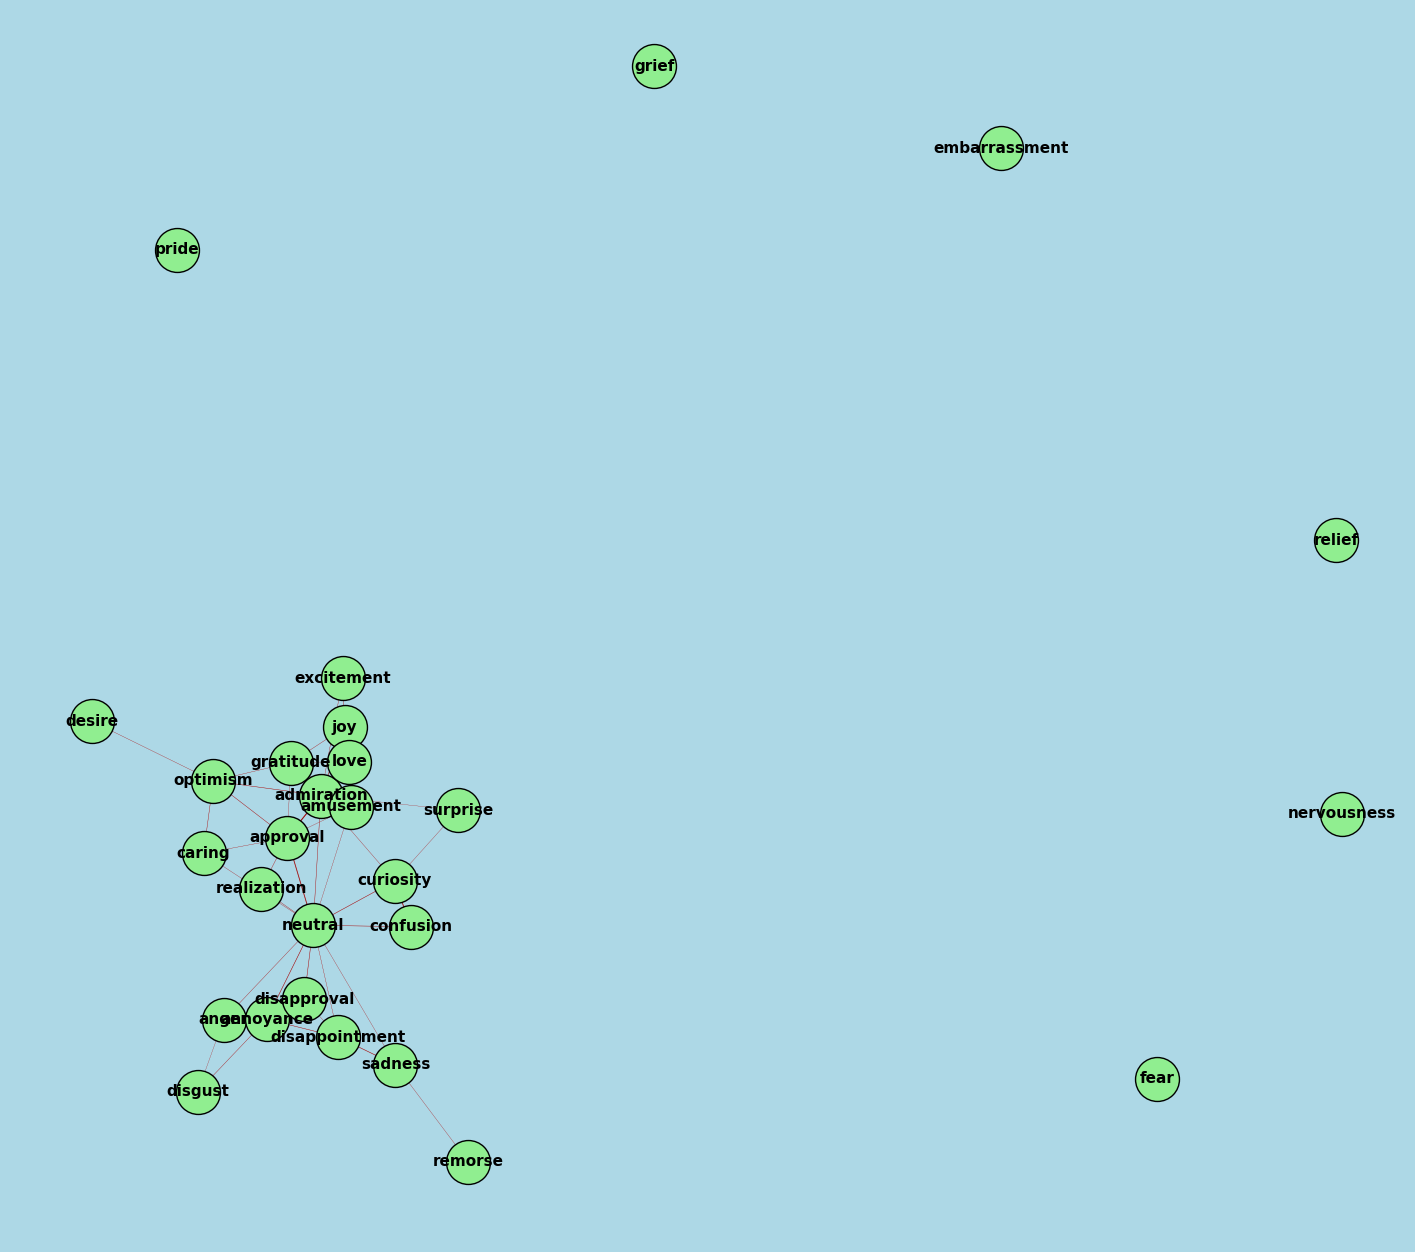

In [13]:
# Import required libraries
import networkx as nx
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# STEP 1: Compute node positions using spring layout
# k controls the distance between nodes (higher = more space)
# iterations controls how much the layout relaxes
# ---------------------------------------------------------
pos = nx.spring_layout(
    G,
    seed=42,
    k=9,          # ⬅️ Increase this if nodes are still close
    iterations=500  # ⬅️ More iterations = better separation
)
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 11
# ---------------------------------------------------------
# STEP 2: Create a large figure for better readability
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(18, 16), facecolor="lightblue")
ax.set_facecolor("lightblue")
# ---------------------------------------------------------
# STEP 3: Draw emotion nodes
# Each node represents an emotion
# ---------------------------------------------------------
nx.draw_networkx_nodes(
    G,
    pos,
    node_size=1000,
    node_color="lightgreen",
    edgecolors="black",
    ax=ax
)

# ---------------------------------------------------------
# STEP 4: Draw edges (emotion co-occurrence)
# Edge width is proportional to co-occurrence strength
# ---------------------------------------------------------
edges = G.edges(data=True)
edge_widths = [data["weight"] / 400 for (_, _, data) in edges]

nx.draw_networkx_edges(
    G,
    pos,
    width=[w * 1.5 for w in edge_widths],
    edge_color="red",
    alpha=0.3,
    ax=ax
)

# Top layer (sharp bold edges)
nx.draw_networkx_edges(
    G,
    pos,
    width=edge_widths,
    edge_color="darkred",
    alpha=0.9,
    ax=ax
)

# ---------------------------------------------------------
# STEP 5: Draw emotion labels
# ---------------------------------------------------------
nx.draw_networkx_labels(
    G,
    pos,
    font_size=11,
    font_color="black",
    font_family="Times New Roman",
    font_weight="bold",
    ax=ax
)

# ---------------------------------------------------------
# STEP 6: Add title and clean up axes
# ---------------------------------------------------------


plt.axis("off")  # Turn off axis for clean visualization

# ---------------------------------------------------------
# STEP 7: Display the graph
# ---------------------------------------------------------
plt.show()


### **Louvain community CLUSTERING**

In [14]:
# Apply Louvain community detection
# Divides the emotion graph into clusters (communities) based on strong co-occurrence relationships
partition = community_louvain.best_partition(
    G,
    random_state=42
)


In [15]:
print(type(partition))
print(len(partition))


<class 'dict'>
28


In [16]:
# Calculate modularity score
# Measures the quality of detected emotion communities-
# Higher value = stronger and well-separated clusters
modularity = community_louvain.modularity(partition, G)
modularity

np.float64(0.38900884865373525)

In [17]:
# Group emotions by their community ID
clusters = {}

for emotion, cluster_id in partition.items():
    clusters.setdefault(cluster_id, []).append(emotion)

# ---- ADD THIS PART ----

# Sort clusters by size (largest cluster first)
sorted_clusters = sorted(clusters.values(), key=lambda x: len(x), reverse=True)

# Reassign stable cluster numbers
stable_clusters = {}
for new_id, emotions in enumerate(sorted_clusters):
    stable_clusters[new_id] = sorted(emotions)   # sort emotions alphabetically for consistency

# Print stable clusters
for cid in stable_clusters:
    print(f"Cluster {cid}: {stable_clusters[cid]}")



Cluster 0: ['admiration', 'amusement', 'approval', 'caring', 'desire', 'excitement', 'gratitude', 'joy', 'love', 'optimism']
Cluster 1: ['anger', 'annoyance', 'disappointment', 'disapproval', 'disgust', 'remorse', 'sadness']
Cluster 2: ['confusion', 'curiosity', 'neutral', 'realization', 'surprise']
Cluster 3: ['embarrassment']
Cluster 4: ['fear']
Cluster 5: ['grief']
Cluster 6: ['nervousness']
Cluster 7: ['pride']
Cluster 8: ['relief']


In [18]:
# Create mapping from emotion ID to emotion name
id_to_emotion = {
    idx: name for idx, name in enumerate(emotion_labels)
}

In [19]:
def label_to_emotion(label):

    # Case 1: label is list  ← YOUR DATASET
    if isinstance(label, list):
        label = label[0]

    # Case 2: label is string like "3,10"
    elif isinstance(label, str):
        label = label.split(',')[0]

    return id_to_emotion[int(label)]


In [20]:
df['emotion'] = df['labels'].apply(label_to_emotion)


In [21]:
df['cluster'] = df['emotion'].map(partition)


In [22]:
cluster_counts = df['cluster'].value_counts().sort_index()
print(cluster_counts)


cluster
0    16795
1       57
2       96
3    17312
4     8222
5      248
6      510
7       65
8      105
Name: count, dtype: int64


In [23]:
cluster_table = cluster_counts.reset_index()
cluster_table.columns = ['Cluster', 'Number_of_Texts']
cluster_table


,Cluster,Number_of_Texts
0,0,16795
1,1,57
2,2,96
3,3,17312
4,4,8222
5,5,248
6,6,510
7,7,65
8,8,105


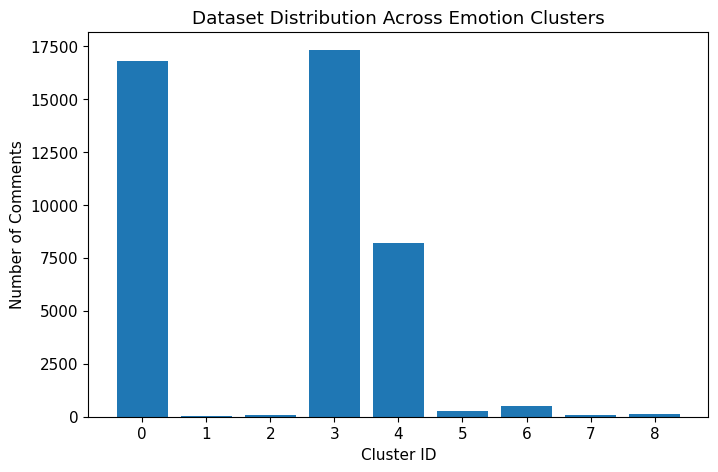

In [24]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'DejaVu Sans'

plt.figure(figsize=(8,5))
plt.bar(cluster_table['Cluster'], cluster_table['Number_of_Texts'])

plt.xlabel("Cluster ID")
plt.ylabel("Number of Comments")
plt.title("Dataset Distribution Across Emotion Clusters")
plt.xticks(cluster_table['Cluster'])

plt.show()

In [25]:
new_dataset = df[['text','cluster']].copy()
new_dataset = new_dataset.dropna()
new_dataset.to_csv("emotion_cluster_dataset.csv", index=False)


In [26]:
import pandas as pd

cluster_table = df['cluster'].value_counts().sort_index().reset_index()
cluster_table.columns = ['Cluster ID', 'Number of Texts']

cluster_table


,Cluster ID,Number of Texts
0,0,16795
1,1,57
2,2,96
3,3,17312
4,4,8222
5,5,248
6,6,510
7,7,65
8,8,105


In [27]:
df[['text','cluster']].head(20)


,text,cluster
0,My favourite food is anything I didn't have to...,3
1,"Now if he does off himself, everyone will thin...",3
2,WHY THE FUCK IS BAYLESS ISOING,4
3,To make her feel threatened,6
4,Dirty Southern Wankers,4
5,OmG pEyToN iSn'T gOoD eNoUgH tO hElP uS iN tHe...,3
6,Yes I heard abt the f bombs! That has to be wh...,0
7,We need more boards and to create a bit more s...,0
8,Damn youtube and outrage drama is super lucrat...,0
9,It might be linked to the trust factor of your...,3


In [28]:
df[['text','cluster']].sample(20, random_state=42)


,text,cluster
25759,The only way this works is if [NAME] is doing ...,3
22531,Access should be hindered it's getting destroyed.,4
18418,Totally fair. All I was trying to remind every...,0
31117,"I'm poly and jn the Raleigh area too, moved he...",3
5733,Naw man Asain men have an easier time. Most of...,0
17987,That scene traumatized me the first time I wat...,6
5343,"No, some of us thought it was gross back then ...",3
7133,Sounds like they’re not responsible and should...,4
23374,It’s awful. I couldn’t even see the ending at ...,4
5304,>West Covina That just happens to be where [NA...,3


drop clusters from 2,5,6,7,8,9 export the dataset as csv

In [29]:
# clusters to remove
drop_clusters = [3,4, 5, 6, 7, 8, 9]

# keep only other clusters
filtered_df = df[~df['cluster'].isin(drop_clusters)].copy()

In [30]:
filtered_df['cluster'].value_counts().sort_index()


,count
cluster,
0,16795
1,57
2,96


In [31]:
filtered_df[['text','cluster']].to_csv("filtered_cluster_dataset.csv", index=False)


# 3 sentences from each **cluster**

In [32]:
for c in sorted(df['cluster'].unique()):
    print(f"\n===== Cluster {c} =====\n")

    sentences = df[df['cluster'] == c]['text'].head(3)

    for s in sentences:
        print(s)


===== Cluster 0 =====

Yes I heard abt the f bombs! That has to be why. Thanks for your reply:) until then hubby and I will anxiously wait 😝
We need more boards and to create a bit more space for [NAME]. Then we’ll be good.
Damn youtube and outrage drama is super lucrative for reddit

===== Cluster 1 =====

I am just like this! Glad to know I’m not imagining it.
So proud our sub is leaking into facebook
I've never been so proud of humanity.

===== Cluster 2 =====

Glad you feel better! My offer still stands though, if you need someone, I’m here
No one comes here it’s cool
I’m glad you fixed Minnesota, because there is a 0% chance we will go Red.

===== Cluster 3 =====

My favourite food is anything I didn't have to cook myself.
Now if he does off himself, everyone will think hes having a laugh screwing with people instead of actually dead
OmG pEyToN iSn'T gOoD eNoUgH tO hElP uS iN tHe PlAyOfFs! Dumbass Broncos fans circa December 2015.

===== Cluster 4 =====

WHY THE FUCK IS BAYLESS I

code each cluster how many dataset

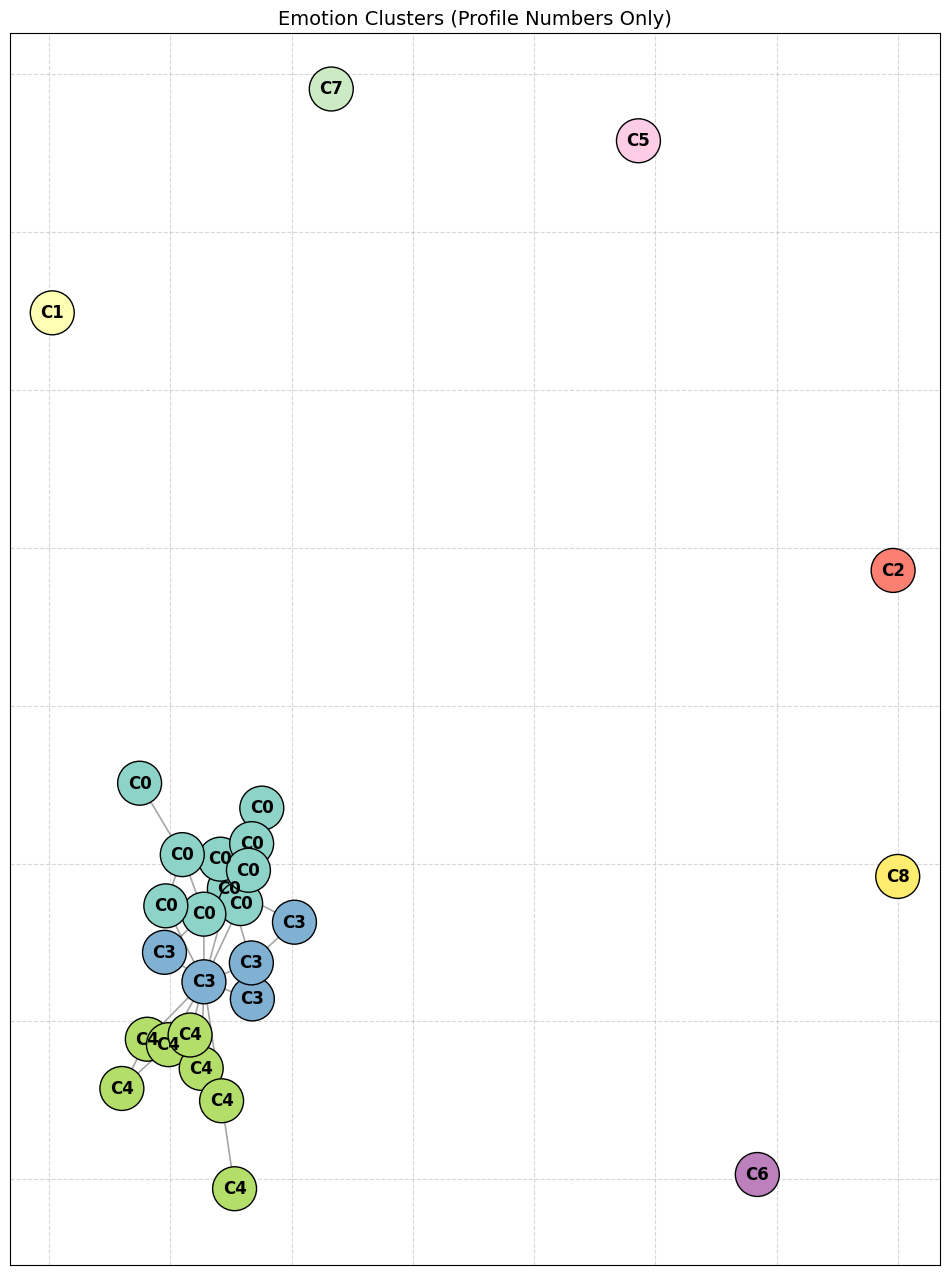

In [33]:
import networkx as nx
import matplotlib.pyplot as plt

# Layout
pos = nx.spring_layout(
    G,
    seed=42,
    k=6.5,
    iterations=500
)

plt.figure(figsize=(12, 16))

# Draw nodes
nx.draw_networkx_nodes(
    G, pos,
    node_color=list(partition.values()),
    cmap=plt.cm.Set3,
    node_size=1000,
    edgecolors="black"
)

# Draw edges
nx.draw_networkx_edges(
    G, pos,
    alpha=0.35,
    width=1.2
)

# Show ONLY cluster numbers
cluster_labels = {node: f"C{partition[node]}" for node in G.nodes()}

nx.draw_networkx_labels(
    G, pos,
    labels=cluster_labels,
    font_size=12,
    font_weight="bold"
)

plt.title("Emotion Clusters (Profile Numbers Only)", fontsize=14)
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

In [34]:
cluster_names = {
    0: "Optimistic and Positive Profile",
    1: "Frustration and Negative Profile",
    2: "Affiliative/Neutral",
    3: "Epistemic Profile",
    4: "Embarrassment",
    5: "Fear",
    6: "Grief",
    7: "Nervousness",
    8: "Pride",
    9: "Relief"
}

In [35]:
profiles_table = pd.DataFrame({
    "Cluster": list(cluster_names.keys()),
    "Profile Name": list(cluster_names.values())
})

print("Identified Emotional Profiles Table:")
print(profiles_table)

Identified Emotional Profiles Table:
   Cluster                      Profile Name
0        0   Optimistic and Positive Profile
1        1  Frustration and Negative Profile
2        2               Affiliative/Neutral
3        3                 Epistemic Profile
4        4                     Embarrassment
5        5                              Fear
6        6                             Grief
7        7                       Nervousness
8        8                             Pride
9        9                            Relief


In [36]:
print(df.columns)

Index(['text', 'labels', 'id', 'emotion', 'cluster'], dtype='object')


In [37]:
df["single_label"] = df["labels"].apply(lambda x: x[0] if isinstance(x, list) else x)

df["profile_label"] = df["single_label"].map(cluster_names)

In [38]:
def get_main_label(label_list):
    if isinstance(label_list, list):
        return label_list[0]   # or use max probability if available
    return label_list

df["single_label"] = df["labels"].apply(get_main_label)
df["profile_label"] = df["single_label"].map(cluster_names)

In [39]:
df["profile_label"] = df["single_label"].map(cluster_names).fillna("Other")

In [40]:
print(df["profile_label"].isna().sum())

0


In [41]:
print("Identified Emotional Profiles Table:")
print(profiles_table)

Identified Emotional Profiles Table:
   Cluster                      Profile Name
0        0   Optimistic and Positive Profile
1        1  Frustration and Negative Profile
2        2               Affiliative/Neutral
3        3                 Epistemic Profile
4        4                     Embarrassment
5        5                              Fear
6        6                             Grief
7        7                       Nervousness
8        8                             Pride
9        9                            Relief


In [42]:
supervised_dataset = df[["text", "profile_label"]]

print("\nNewly Formed Supervised Dataset:")
print(supervised_dataset.head(10))


Newly Formed Supervised Dataset:
                                                text  \
0  My favourite food is anything I didn't have to...   
1  Now if he does off himself, everyone will thin...   
2                     WHY THE FUCK IS BAYLESS ISOING   
3                        To make her feel threatened   
4                             Dirty Southern Wankers   
5  OmG pEyToN iSn'T gOoD eNoUgH tO hElP uS iN tHe...   
6  Yes I heard abt the f bombs! That has to be wh...   
7  We need more boards and to create a bit more s...   
8  Damn youtube and outrage drama is super lucrat...   
9  It might be linked to the trust factor of your...   

                     profile_label  
0                            Other  
1                            Other  
2              Affiliative/Neutral  
3                            Other  
4                Epistemic Profile  
5                            Other  
6                            Other  
7                            Pride  
8  Optimistic an

Save Supervised Dataset

In [43]:
supervised_dataset.to_csv('supervised_dataset.csv', index=False)

In [44]:
df["profile_label"] = df["single_label"].map(cluster_names).fillna("Other")

In [45]:
emotion_list = [
    'admiration','amusement','anger','annoyance','approval','caring',
    'confusion','curiosity','desire','disappointment','disapproval',
    'disgust','embarrassment','excitement','fear','gratitude','grief',
    'joy','love','nervousness','optimism','pride','realization',
    'relief','remorse','sadness','surprise','neutral'
]

index_to_emotion = {i: emotion for i, emotion in enumerate(emotion_list)}

In [46]:
emotion_to_profile = {
    # 🔴 Frustration-Negative
    'anger': 'Frustration and Negative Profile',
    'annoyance': 'Frustration and Negative Profile',
    'disappointment': 'Frustration and Negative Profile',
    'disapproval': 'Frustration and Negative Profile',
    'disgust': 'Frustration and Negative Profile',
    'remorse': 'Frustration and Negative Profile',
    'sadness': 'Frustration and Negative Profile',
    'grief': 'Frustration and Negative Profile',

    # 🟢 Optimistic-Positive
    'admiration': 'Optimistic and Positive Profile',
    'amusement': 'Optimistic and Positive Profile',
    'excitement': 'Optimistic and Positive Profile',
    'gratitude': 'Optimistic and Positive Profile',
    'joy': 'Optimistic and Positive Profile',
    'love': 'Optimistic and Positive Profile',
    'optimism': 'Optimistic and Positive Profile',
    'pride': 'Optimistic and Positive Profile',
    'relief': 'Optimistic and Positive Profile',

    # 🔵 Epistemic
    'confusion': 'Epistemic Profile',
    'curiosity': 'Epistemic Profile',
    'surprise': 'Epistemic Profile',
    'realization': 'Epistemic Profile',

    # ⚪ Neutral / Social
    'approval': 'Affiliative/Neutral',
    'caring': 'Affiliative/Neutral',
    'desire': 'Affiliative/Neutral',
    'neutral': 'Affiliative/Neutral',

    # ⚫ Others
    'fear': 'Fear',
    'nervousness': 'Nervousness',
    'embarrassment': 'Embarrassment'
}

In [47]:
# Step 1
df["emotion_name"] = df["single_label"].map(index_to_emotion)

# Step 2
df["profile_label"] = df["emotion_name"].map(emotion_to_profile)

In [48]:
print(df["profile_label"].isna().sum())

0


# **Identified Emotional Profiles Table**

In [49]:
# Create Identified Profiles Table
profiles_table = pd.DataFrame({
    "Profile Name": [
        "Optimistic and Positive Profile",
        "Frustration and Negative Profile",
        "Epistemic Profile",
        "Affiliative/Neutral",
        "Fear",
        "Nervousness",
        "Embarrassment"
    ],
    "Description": [
        "Includes emotions like joy, love, optimism, excitement, gratitude",
        "Includes anger, sadness, disgust, disappointment, remorse",
        "Includes curiosity, confusion, realization, surprise",
        "Includes neutral, approval, caring, desire",
        "Fear-related emotional state",
        "Anxiety and nervous anticipation",
        "Self-conscious emotional discomfort"
    ]
})

print("Identified Emotional Profiles Table:")
print(profiles_table)

Identified Emotional Profiles Table:
                       Profile Name  \
0   Optimistic and Positive Profile   
1  Frustration and Negative Profile   
2                 Epistemic Profile   
3               Affiliative/Neutral   
4                              Fear   
5                       Nervousness   
6                     Embarrassment   

                                         Description  
0  Includes emotions like joy, love, optimism, ex...  
1  Includes anger, sadness, disgust, disappointme...  
2  Includes curiosity, confusion, realization, su...  
3         Includes neutral, approval, caring, desire  
4                       Fear-related emotional state  
5                   Anxiety and nervous anticipation  
6                Self-conscious emotional discomfort  


In [50]:
# Step 1: Group by profile
profile_groups = df.groupby("profile_label")["emotion_name"].apply(list)

# Step 2: Get top 3 emotions
def get_top_emotions(emotions_list):
    return list(pd.Series(emotions_list).value_counts().head(3).index)

# Step 3: Apply
top_emotions = profile_groups.apply(get_top_emotions)

In [51]:
# Create final clean table
final_table = pd.DataFrame({
    "Cluster": list(range(len(top_emotions))),
    "Top Emotions": top_emotions.values,
    "Profile Label": top_emotions.apply(lambda x: " + ".join(x)).values
})

# Add S.No
final_table = final_table.reset_index(drop=True)
final_table.index = final_table.index + 1
final_table.index.name = "S.No"

# Convert list to string (VERY IMPORTANT FIX)
final_table["Top Emotions"] = final_table["Top Emotions"].apply(lambda x: ", ".join(x))

print(final_table.to_string())

      Cluster                      Top Emotions                       Profile Label
S.No                                                                               
1           0         neutral, approval, caring         neutral + approval + caring
2           1                     embarrassment                       embarrassment
3           2    curiosity, confusion, surprise    curiosity + confusion + surprise
4           3                              fear                                fear
5           4     annoyance, disapproval, anger     annoyance + disapproval + anger
6           5                       nervousness                         nervousness
7           6  admiration, amusement, gratitude  admiration + amusement + gratitude


# **Newly Formed Supervised Dataset Table**

In [52]:
df["single_label"] = df["labels"].apply(lambda x: x[0] if isinstance(x, list) else x)

In [53]:

supervised_dataset.head(10).reset_index().rename(
columns={"index": "S.No", "text": "Text", "profile_label": "Profile Label"}
)

,S.No,Text,Profile Label
0,0,My favourite food is anything I didn't have to...,Other
1,1,"Now if he does off himself, everyone will thin...",Other
2,2,WHY THE FUCK IS BAYLESS ISOING,Affiliative/Neutral
3,3,To make her feel threatened,Other
4,4,Dirty Southern Wankers,Epistemic Profile
5,5,OmG pEyToN iSn'T gOoD eNoUgH tO hElP uS iN tHe...,Other
6,6,Yes I heard abt the f bombs! That has to be wh...,Other
7,7,We need more boards and to create a bit more s...,Pride
8,8,Damn youtube and outrage drama is super lucrat...,Optimistic and Positive Profile
9,9,It might be linked to the trust factor of your...,Other


In [54]:
profiles_table.to_csv("identified_profiles.csv", index=False)
supervised_dataset.to_csv("supervised_dataset.csv", index=False)

In [55]:
df["emotion_name"]
df["profile_label"]

,profile_label
0,Affiliative/Neutral
1,Affiliative/Neutral
2,Frustration and Negative Profile
3,Fear
4,Frustration and Negative Profile
...,...
43405,Optimistic and Positive Profile
43406,Epistemic Profile
43407,Frustration and Negative Profile
43408,Optimistic and Positive Profile


In [56]:
df["emotion_name"] = df["single_label"].map(index_to_emotion)
df["profile_label"] = df["emotion_name"].map(emotion_to_profile)

In [57]:
print(df.columns)

Index(['text', 'labels', 'id', 'emotion', 'cluster', 'single_label',
       'profile_label', 'emotion_name'],
      dtype='object')


In [58]:
table = df[["text", "profile_label"]].head(10).copy()

table.insert(0, "S.No", range(1, len(table) + 1))
table.columns = ["S.No", "Text", "Profile Label"]

print(table.to_string(index=False))

 S.No                                                                                                                  Text                    Profile Label
    1                                                           My favourite food is anything I didn't have to cook myself.              Affiliative/Neutral
    2      Now if he does off himself, everyone will think hes having a laugh screwing with people instead of actually dead              Affiliative/Neutral
    3                                                                                        WHY THE FUCK IS BAYLESS ISOING Frustration and Negative Profile
    4                                                                                           To make her feel threatened                             Fear
    5                                                                                                Dirty Southern Wankers Frustration and Negative Profile
    6                    OmG pEyToN iSn'T gOoD eNoUgH tO h

In [59]:
final_table.to_csv("identified_profiles_table.csv", index=False)

In [60]:
supervised_dataset = df[["text", "profile_label"]]

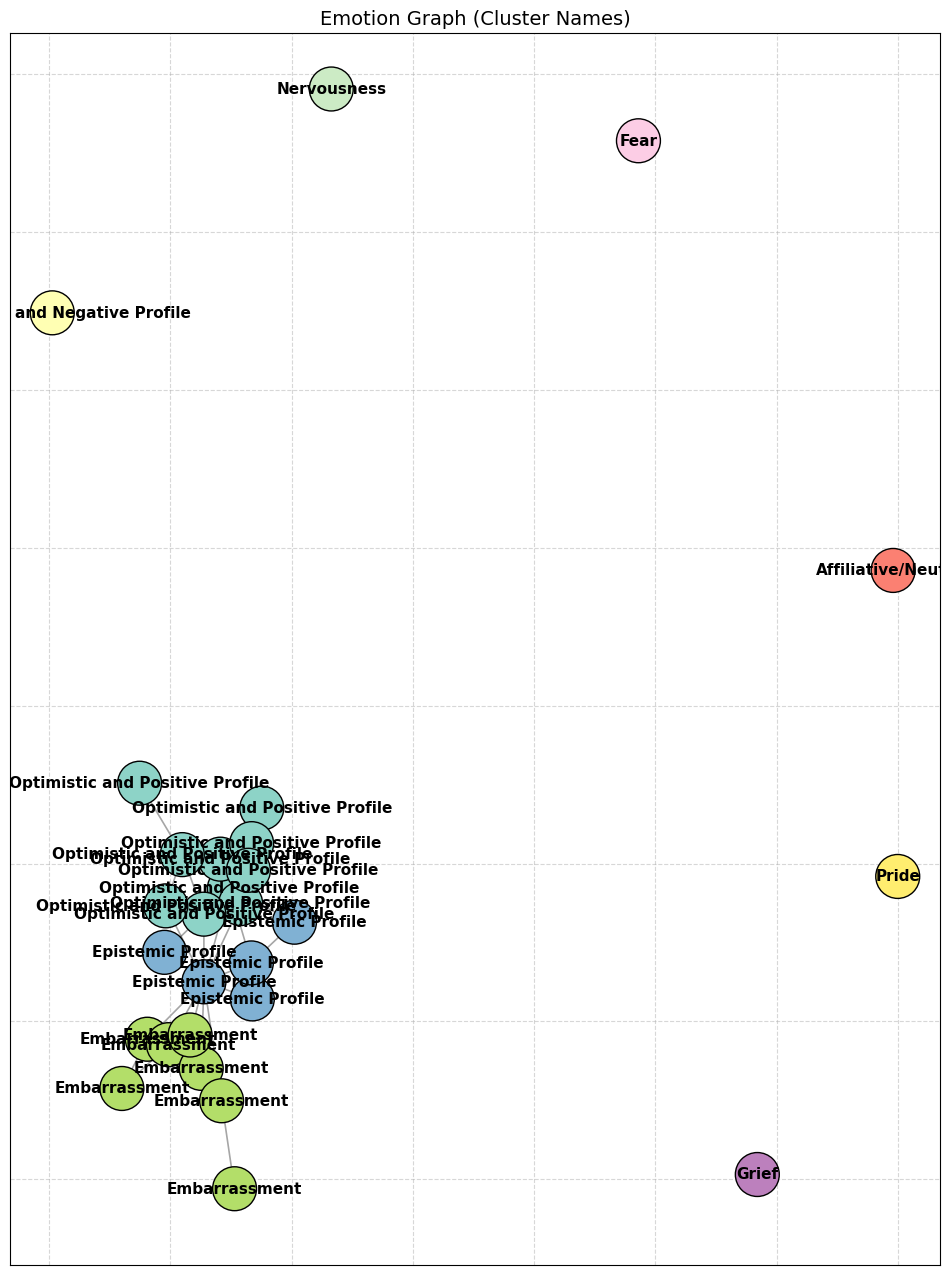

In [61]:
import networkx as nx
import matplotlib.pyplot as plt

# Layout
pos = nx.spring_layout(
    G,
    seed=42,
    k=6.5,
    iterations=500
)

plt.figure(figsize=(12, 16))

# Draw nodes
nx.draw_networkx_nodes(
    G, pos,
    node_color=list(partition.values()),
    cmap=plt.cm.Set3,
    node_size=1000,
    edgecolors="black"
)

# Draw edges
nx.draw_networkx_edges(
    G, pos,
    alpha=0.35,
    width=1.2
)

# ---------------------------------------
# Label nodes using cluster names
# ---------------------------------------

cluster_labels = {
    node: cluster_names.get(partition[node], f"C{partition[node]}")
    for node in G.nodes()
}

nx.draw_networkx_labels(
    G, pos,
    labels=cluster_labels,
    font_size=11,
    font_weight="bold"
)

plt.title("Emotion Graph (Cluster Names)", fontsize=14)
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

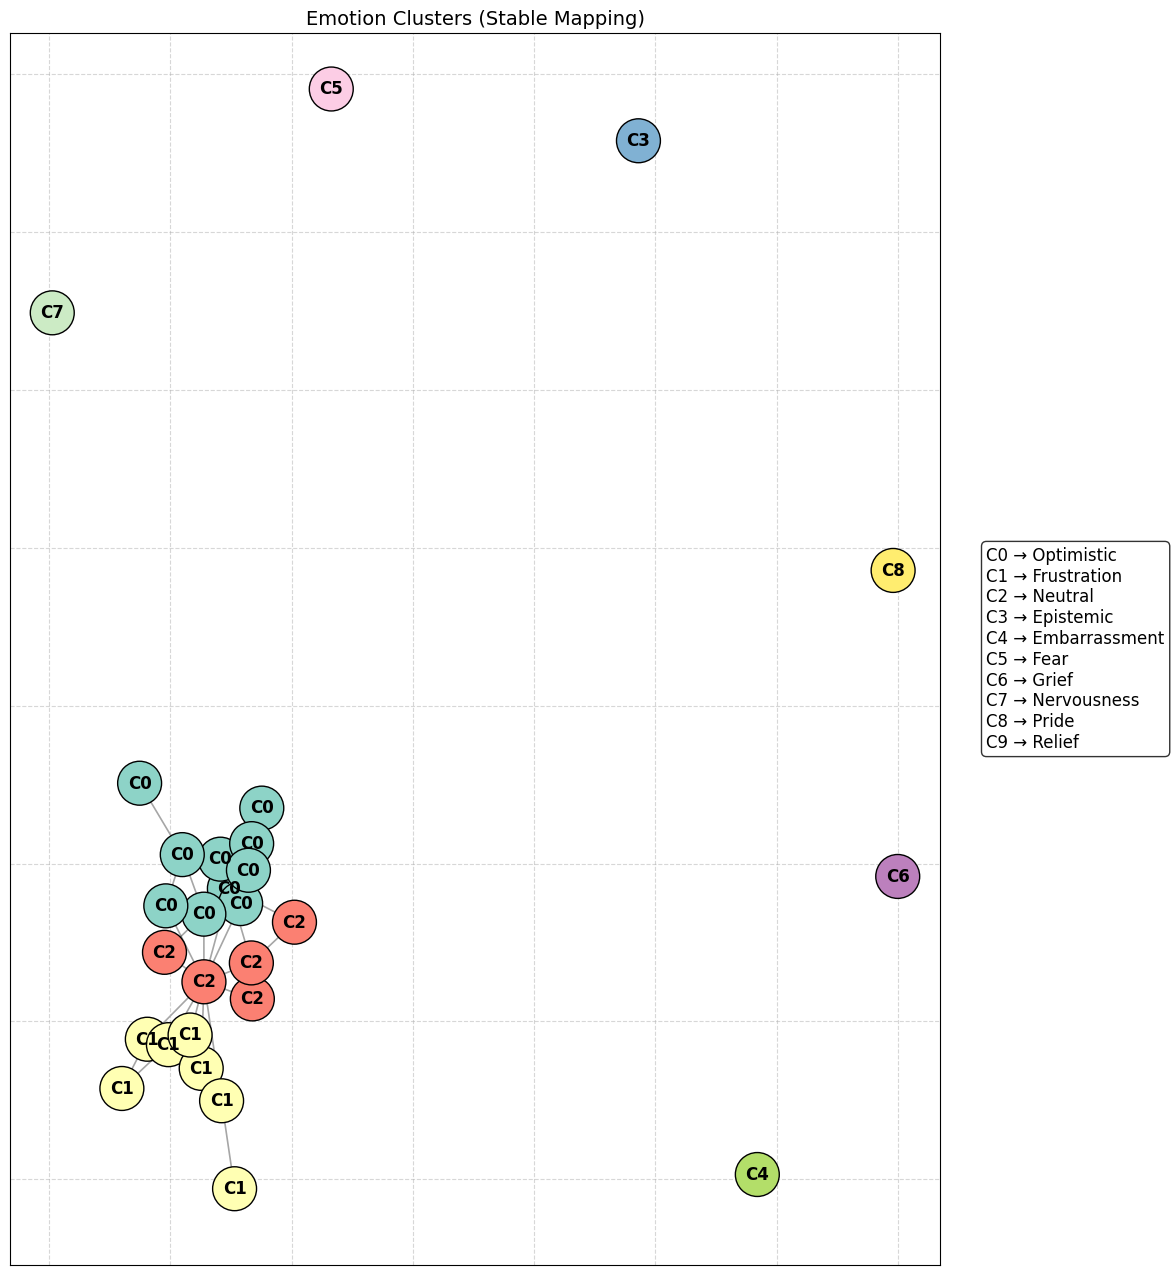

In [62]:
import networkx as nx
import matplotlib.pyplot as plt

# -------------------------------
# STEP 1: Create clusters
# -------------------------------
clusters = {}
for emotion, cluster_id in partition.items():
    clusters.setdefault(cluster_id, []).append(emotion)

# -------------------------------
# STEP 2: Make clusters stable
# -------------------------------
sorted_clusters = sorted(clusters.values(), key=lambda x: len(x), reverse=True)

stable_clusters = {}
for new_id, emotions in enumerate(sorted_clusters):
    stable_clusters[new_id] = sorted(emotions)

# -------------------------------
# STEP 3: Create mapping
# -------------------------------
emotion_to_cluster = {}
for new_id, emotions in stable_clusters.items():
    for emo in emotions:
        emotion_to_cluster[emo] = new_id

# -------------------------------
# STEP 4: Graph Layout
# -------------------------------
pos = nx.spring_layout(G, seed=42, k=6.5, iterations=500)

plt.figure(figsize=(12, 16))

# -------------------------------
# STEP 5: Draw nodes (FIXED)
# -------------------------------
nx.draw_networkx_nodes(
    G,
    pos,
    node_color=[emotion_to_cluster[node] for node in G.nodes()],
    cmap=plt.cm.Set3,
    node_size=1000,
    edgecolors="black"
)

# -------------------------------
# STEP 6: Draw edges
# -------------------------------
nx.draw_networkx_edges(
    G,
    pos,
    alpha=0.35,
    width=1.2
)

# -------------------------------
# STEP 7: Labels
# -------------------------------
cluster_labels = {
    node: f"C{emotion_to_cluster[node]}" for node in G.nodes()
}

nx.draw_networkx_labels(
    G,
    pos,
    labels=cluster_labels,
    font_size=12,
    font_weight="bold"
)

# -------------------------------
# STEP 8: Legend (FIXED ERROR)
# -------------------------------
cluster_legend = {
    "C0": "Optimistic",
    "C1": "Frustration",
    "C2": "Neutral",
    "C3": "Epistemic",
    "C4": "Embarrassment",
    "C5": "Fear",
    "C6": "Grief",
    "C7": "Nervousness",
    "C8": "Pride",
    "C9": "Relief"
}

legend_text = "\n".join([f"{k} → {v}" for k, v in cluster_legend.items()])

plt.text(
    1.05, 0.5,
    legend_text,
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment="center",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

# -------------------------------
# STEP 9: Final plot
# -------------------------------
plt.title("Emotion Clusters (Stable Mapping)", fontsize=14)
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

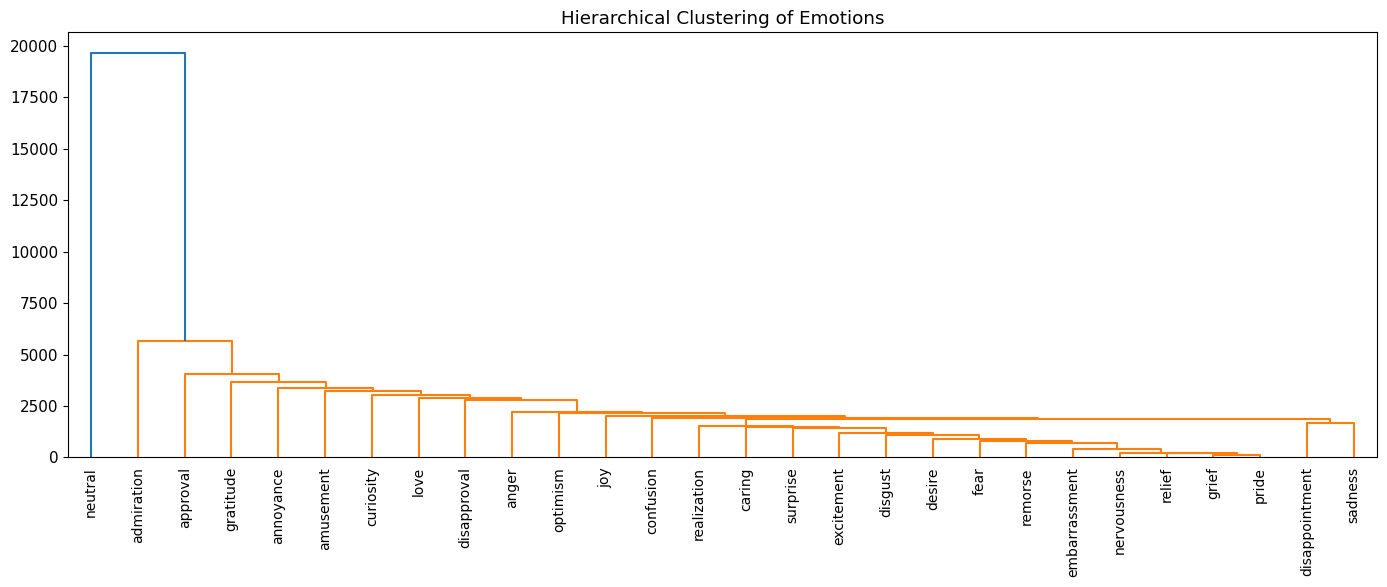

In [63]:
# Perform hierarchical clustering and plot dendrogram
# Shows how emotions group together based on similarity
linked = linkage(co_occurrence, method="ward")

plt.figure(figsize=(14, 6))
dendrogram(linked, labels=emotion_labels, leaf_rotation=90)
plt.title("Hierarchical Clustering of Emotions")
plt.tight_layout()
plt.show()


Count Of Each **Cluster**

In [64]:
# Count number of emotions per cluster
from collections import Counter

cluster_counts = Counter(partition.values())

# Print in order
for cid in sorted(cluster_counts):
    print(f"Cluster {cid}: {cluster_counts[cid]} emotions")

Cluster 0: 10 emotions
Cluster 1: 1 emotions
Cluster 2: 1 emotions
Cluster 3: 5 emotions
Cluster 4: 7 emotions
Cluster 5: 1 emotions
Cluster 6: 1 emotions
Cluster 7: 1 emotions
Cluster 8: 1 emotions


# **Table**

In [65]:
import pandas as pd

cluster_table = pd.DataFrame(
    sorted(cluster_counts.items()),
    columns=["Cluster ID", "Number of Emotions"]
)

cluster_table

,Cluster ID,Number of Emotions
0,0,10
1,1,1
2,2,1
3,3,5
4,4,7
5,5,1
6,6,1
7,7,1
8,8,1


# **Visualize Cluster Distribution (Bar Chart)**

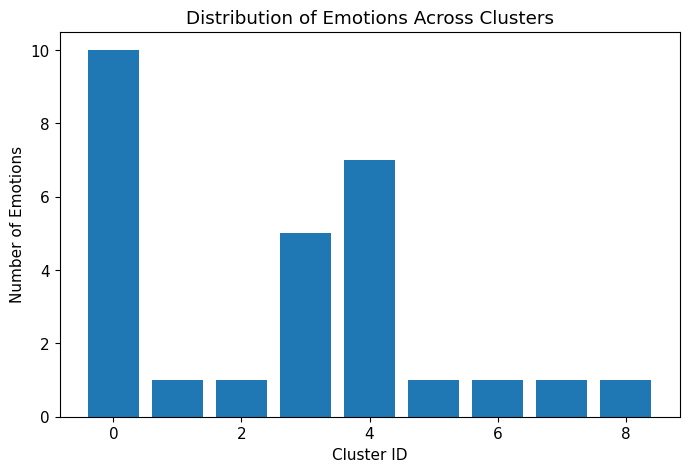

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(cluster_table["Cluster ID"],
        cluster_table["Number of Emotions"])

plt.xlabel("Cluster ID")
plt.ylabel("Number of Emotions")
plt.title("Distribution of Emotions Across Clusters")

plt.show()

In [67]:
# =========================================================
# STEP 1: Define Research-Based Emotional Profiles
# =========================================================

FRUSTRATION_NEGATIVE_PROFILE = {
    "anger", "annoyance", "disappointment",
    "disapproval", "disgust", "remorse", "sadness"
}

OPTIMISTIC_POSITIVE_PROFILE = {
    "admiration", "amusement", "excitement",
    "gratitude", "joy", "love"
}

EPISTEMIC_PROFILE = {
    "confusion", "curiosity", "surprise"
}


# =========================================================
# STEP 2: Strict Profile Detection Function
# (Requires at least 2 emotions from same profile)
# =========================================================

def detect_emotion_profile(emotions):

    emotions = set(emotions)
    profiles = []

    # Frustration & Negative Profile
    if len(emotions.intersection(FRUSTRATION_NEGATIVE_PROFILE)) >= 2:
        profiles.append("Frustration and Negative Profile")

    # Optimistic & Positive Profile
    if len(emotions.intersection(OPTIMISTIC_POSITIVE_PROFILE)) >= 2:
        profiles.append("Optimistic and Positive Profile")

    # Epistemic Profile
    if len(emotions.intersection(EPISTEMIC_PROFILE)) >= 2:
        profiles.append("Epistemic Profile")

    return profiles if profiles else None   # Return None instead of "No Profile"


# =========================================================
# STEP 3: Apply Profile Detection to Dataset
# =========================================================

# If your emotions are numerical, convert first
df["emotion_names"] = df["labels"].apply(
    lambda labels: [emotion_labels[i] for i in labels]
)

# Apply detection
df["emotion_profile"] = df["emotion_names"].apply(detect_emotion_profile)


# =========================================================
# STEP 4: Remove Posts Without Dominant Profile
# =========================================================

df_clean = df[df["emotion_profile"].notna()].copy()


# =========================================================
# STEP 5: Keep Only One Profile Per Post (Optional Cleaner)
# =========================================================

df_clean["emotion_profile"] = df_clean["emotion_profile"].apply(lambda x: x[0])


# =========================================================
# STEP 6: Count Profile Distribution
# =========================================================

from collections import Counter

profile_counts = Counter(df_clean["emotion_profile"])

for profile, count in profile_counts.items():
    print(f"{profile}: {count}")


# =========================================================
# STEP 7: Display Clean Research Table
# =========================================================

df_clean[["text", "emotion_names", "emotion_profile"]].head(15)

Optimistic and Positive Profile: 1197
Epistemic Profile: 278
Frustration and Negative Profile: 1048


,text,emotion_names,emotion_profile
40,"aw, thanks! I appreciate that!","[admiration, gratitude]",Optimistic and Positive Profile
41,Thanks! I love watching him every week,"[gratitude, love]",Optimistic and Positive Profile
54,Very interesting. Thx,"[excitement, gratitude]",Optimistic and Positive Profile
60,LOL. Super cute!,"[admiration, amusement]",Optimistic and Positive Profile
65,Awesome. Thanks!,"[admiration, gratitude]",Optimistic and Positive Profile
76,"Awesome! I’m a cradle [RELIGION], so really in...","[admiration, excitement, gratitude]",Optimistic and Positive Profile
86,Thank you for at least doing something good sir.,"[admiration, gratitude]",Optimistic and Positive Profile
107,Who is this Wild team? Where have they been?,"[confusion, curiosity]",Epistemic Profile
124,[NAME] dude I see [NAME] so rarely that I forg...,"[anger, annoyance]",Frustration and Negative Profile
129,Tournament was a blast met some really cool pe...,"[admiration, desire, gratitude, joy]",Optimistic and Positive Profile


In [68]:
df["emotion_profile"].value_counts()


,count
emotion_profile,
[Optimistic and Positive Profile],1195
[Frustration and Negative Profile],1045
[Epistemic Profile],278
"[Frustration and Negative Profile, Optimistic and Positive Profile]",3
"[Optimistic and Positive Profile, Epistemic Profile]",2


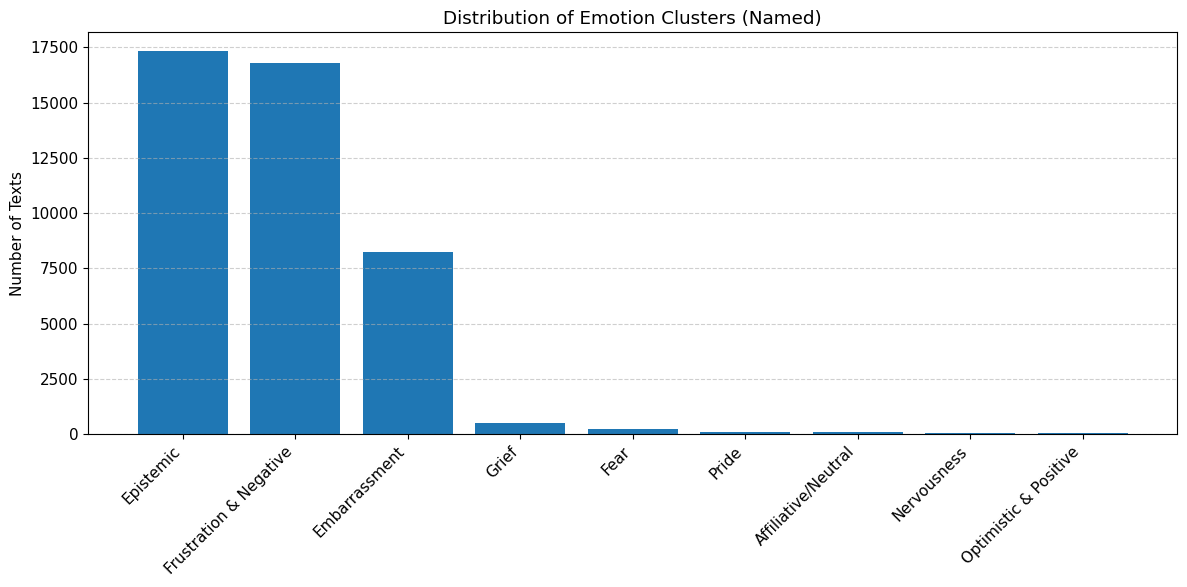

In [69]:
cluster_name_map = {
    0: "Frustration & Negative",
    1: "Optimistic & Positive",
    2: "Affiliative/Neutral",
    3: "Epistemic",
    4: "Embarrassment",
    5: "Fear",
    6: "Grief",
    7: "Nervousness",
    8: "Pride",
    9: "Relief"
}

df["cluster_name"] = df["cluster"].map(cluster_name_map)

cluster_counts = df["cluster_name"].value_counts()

plt.figure(figsize=(12,6))
bars = plt.bar(cluster_counts.index, cluster_counts.values)

plt.xticks(rotation=45, ha="right")
plt.title("Distribution of Emotion Clusters (Named)")
plt.ylabel("Number of Texts")
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

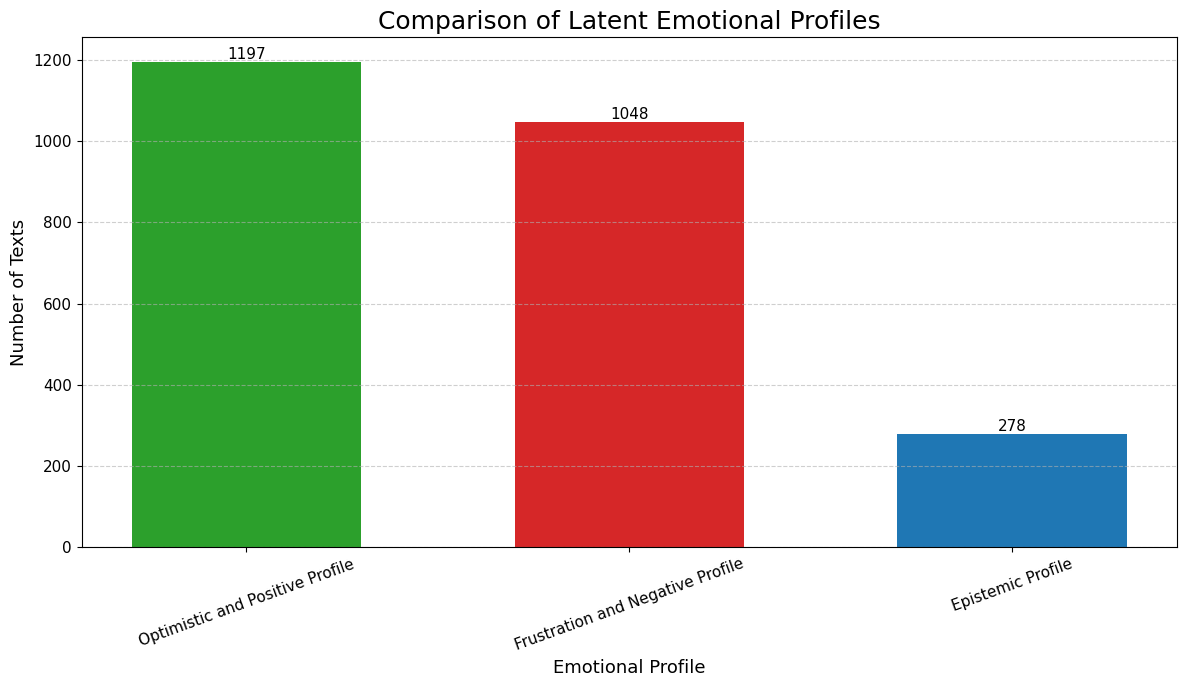

In [70]:
import matplotlib.pyplot as plt

# -----------------------------------------
# Step 1: Get profile counts
# -----------------------------------------
profile_counts = df_clean["emotion_profile"].value_counts()

# -----------------------------------------
# Step 2: Define custom colors for each profile
# -----------------------------------------
color_map = {
    "Frustration and Negative Profile": "#d62728",   # red
    "Optimistic and Positive Profile": "#2ca02c",    # green
    "Epistemic Profile": "#1f77b4"                   # blue
}

# Match colors to profiles
colors = [color_map.get(profile, "#7f7f7f") for profile in profile_counts.index]

# -----------------------------------------
# Step 3: Create Figure
# -----------------------------------------
plt.figure(figsize=(12,7))

bars = plt.bar(
    profile_counts.index,
    profile_counts.values,
    color=colors,
    width=0.6
)

# -----------------------------------------
# Step 4: Titles and Labels
# -----------------------------------------
plt.title("Comparison of Latent Emotional Profiles", fontsize=18)
plt.xlabel("Emotional Profile", fontsize=13)
plt.ylabel("Number of Texts", fontsize=13)

plt.xticks(rotation=20)
plt.grid(axis="y", linestyle="--", alpha=0.6)

# -----------------------------------------
# Step 5: Add Count Labels on Bars
# -----------------------------------------
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        str(height),
        ha='center',
        va='bottom',
        fontsize=11
    )

# -----------------------------------------
# Step 6: Adjust Layout
# -----------------------------------------
plt.tight_layout()
plt.show()

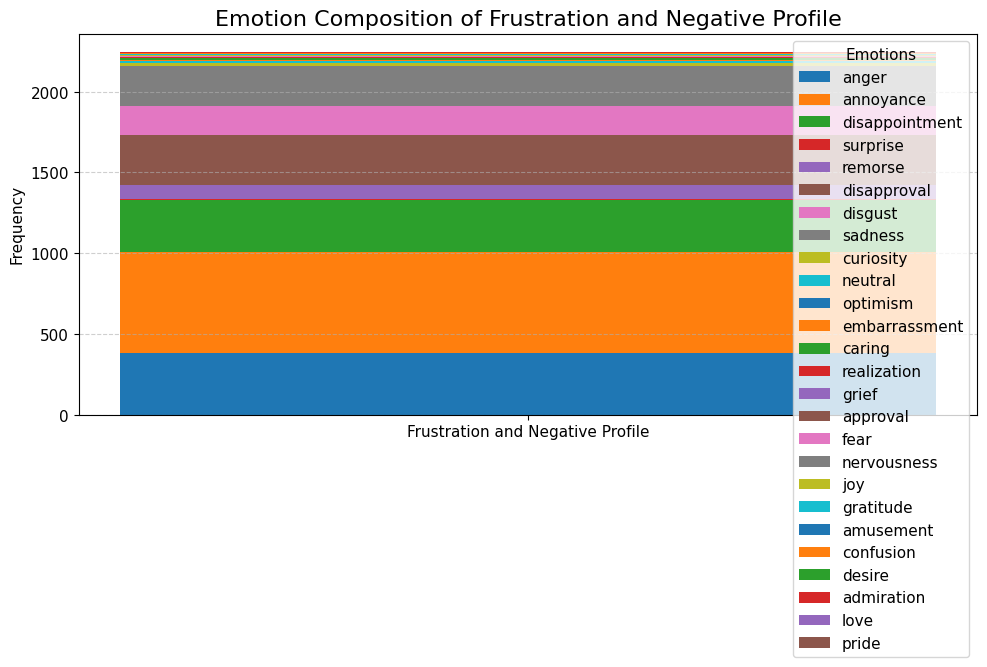

In [71]:
import matplotlib.pyplot as plt
from collections import Counter

# -----------------------------------------
# Step 1: Choose Profile
# -----------------------------------------
selected_profile = "Frustration and Negative Profile"

# Filter posts for this profile
df_profile = df_clean[df_clean["emotion_profile"] == selected_profile]

# -----------------------------------------
# Step 2: Count emotions inside profile
# -----------------------------------------
emotion_counter = Counter()

for emotions in df_profile["emotion_names"]:
    emotion_counter.update(emotions)

# -----------------------------------------
# Step 3: Prepare stacked bar
# -----------------------------------------
emotions = list(emotion_counter.keys())
counts = list(emotion_counter.values())

plt.figure(figsize=(10,6))

bottom = 0
colors = plt.cm.tab10.colors  # automatic distinct colors

for i, emotion in enumerate(emotions):
    plt.bar(
        selected_profile,
        counts[i],
        bottom=bottom,
        label=emotion,
        color=colors[i % len(colors)]
    )
    bottom += counts[i]

# -----------------------------------------
# Step 4: Styling
# -----------------------------------------
plt.title(f"Emotion Composition of {selected_profile}", fontsize=16)
plt.ylabel("Frequency")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.legend(title="Emotions")
plt.tight_layout()
plt.show()

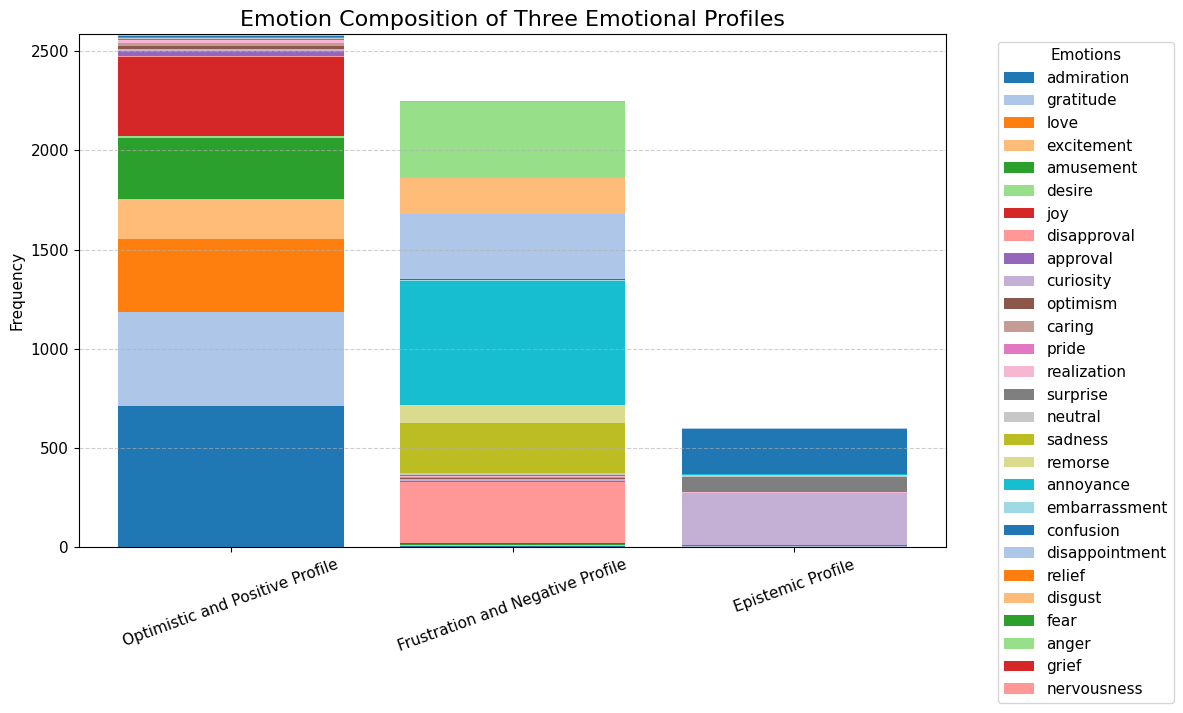

In [72]:
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd

# -----------------------------------------
# Step 1: Define your 3 profiles
# -----------------------------------------
profiles = [
    "Optimistic and Positive Profile",
    "Frustration and Negative Profile",
    "Epistemic Profile"
]

# -----------------------------------------
# Step 2: Count emotions inside each profile
# -----------------------------------------
profile_emotion_counts = {}

for profile in profiles:
    df_profile = df_clean[df_clean["emotion_profile"] == profile]
    counter = Counter()

    for emotions in df_profile["emotion_names"]:
        counter.update(emotions)

    profile_emotion_counts[profile] = counter

# -----------------------------------------
# Step 3: Convert to DataFrame
# -----------------------------------------
emotion_df = pd.DataFrame(profile_emotion_counts).fillna(0)

# -----------------------------------------
# Step 4: Plot stacked bar chart
# -----------------------------------------
plt.figure(figsize=(12,7))

bottom = [0] * len(profiles)

colors = plt.cm.tab20.colors  # many distinct colors

for i, emotion in enumerate(emotion_df.index):
    values = emotion_df.loc[emotion].values

    plt.bar(
        profiles,
        values,
        bottom=bottom,
        label=emotion,
        color=colors[i % len(colors)]
    )

    bottom = [bottom[j] + values[j] for j in range(len(values))]

# -----------------------------------------
# Step 5: Styling
# -----------------------------------------
plt.title("Emotion Composition of Three Emotional Profiles", fontsize=16)
plt.ylabel("Frequency")
plt.xticks(rotation=20)
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.legend(title="Emotions", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

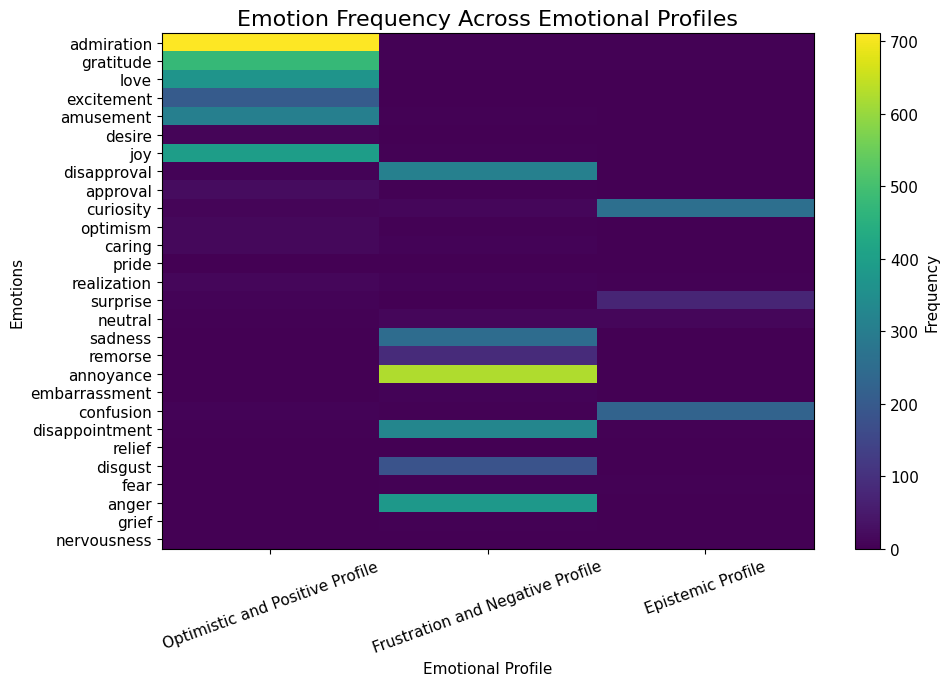

In [73]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

# -----------------------------------------
# Step 1: Define your 3 profiles
# -----------------------------------------
profiles = [
    "Optimistic and Positive Profile",
    "Frustration and Negative Profile",
    "Epistemic Profile"
]

# -----------------------------------------
# Step 2: Count emotions inside each profile
# -----------------------------------------
profile_emotion_counts = {}

for profile in profiles:
    df_profile = df_clean[df_clean["emotion_profile"] == profile]
    counter = Counter()

    for emotions in df_profile["emotion_names"]:
        counter.update(emotions)

    profile_emotion_counts[profile] = counter

# -----------------------------------------
# Step 3: Convert to DataFrame
# -----------------------------------------
emotion_df = pd.DataFrame(profile_emotion_counts).fillna(0)

# -----------------------------------------
# Step 4: Plot Heatmap
# -----------------------------------------
plt.figure(figsize=(10,7))

heatmap = plt.imshow(
    emotion_df,
    cmap="viridis",
    aspect="auto"
)

plt.colorbar(label="Frequency")

plt.xticks(
    ticks=np.arange(len(profiles)),
    labels=profiles,
    rotation=20
)

plt.yticks(
    ticks=np.arange(len(emotion_df.index)),
    labels=emotion_df.index
)

plt.title("Emotion Frequency Across Emotional Profiles", fontsize=16)
plt.xlabel("Emotional Profile")
plt.ylabel("Emotions")

plt.tight_layout()
plt.show()

In [74]:
# Convert list values to string (if any)
df["emotion_profile"] = df["emotion_profile"].apply(
    lambda x: x[0] if isinstance(x, list) else x
)

df["cluster_name"] = df["cluster_name"].apply(
    lambda x: x[0] if isinstance(x, list) else x
)

# **Cluster-Based vs Theory-Based Profile Comparison**

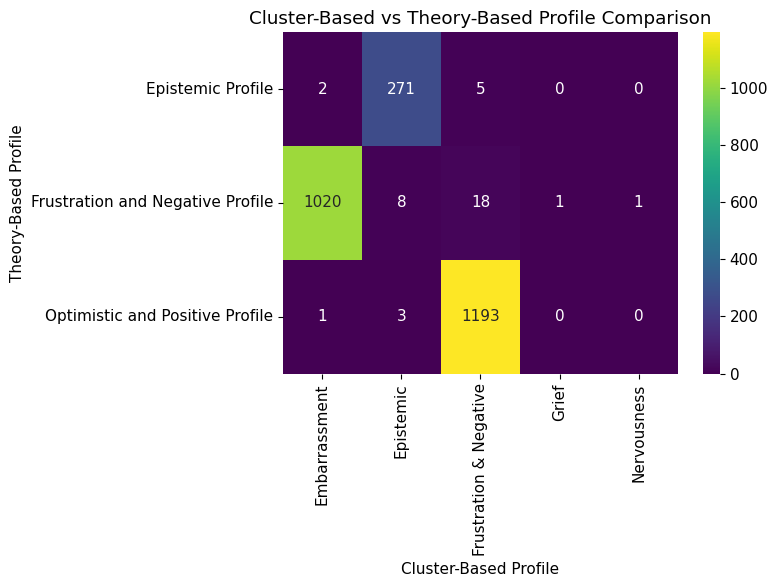

In [75]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_compare = df[df["emotion_profile"].notna()].copy()

conf_matrix = pd.crosstab(
    df_compare["emotion_profile"],
    df_compare["cluster_name"]
)

plt.figure(figsize=(8,6))

sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="viridis"
)

plt.title("Cluster-Based vs Theory-Based Profile Comparison")
plt.xlabel("Cluster-Based Profile")
plt.ylabel("Theory-Based Profile")

plt.tight_layout()
plt.show()

In [76]:
# ============================================================
# CREATE TRUE 3-PROFILE DATASET
# ============================================================

# Step 1: Ensure profile column is string (not list)
df["emotion_profile"] = df["emotion_profile"].apply(
    lambda x: x[0] if isinstance(x, list) else x
)

# Step 2: Define 3-profile mapping
profile_mapping = {

    # PROFILE 0 – Epistemic (Cognitive)
    "Epistemic Profile": 0,

    # PROFILE 1 – Optimistic / Positive
    "Optimistic and Positive Profile": 1,

    # PROFILE 2 – Frustration / Negative
    "Frustration and Negative Profile": 2,
}

# Step 3: Create new dataframe
df_3profile = df[['text', 'emotion_profile']].copy()

# Remove missing profiles
df_3profile = df_3profile.dropna()

# Step 4: Map to numeric labels
df_3profile['profile'] = df_3profile['emotion_profile'].map(profile_mapping)

# Remove any unmapped rows
df_3profile = df_3profile.dropna()

df_3profile['profile'] = df_3profile['profile'].astype(int)

# Step 5: Print results
print("3-Profile Labels:")
print(sorted(df_3profile['profile'].unique()))

print("\nClass Distribution:")
print(df_3profile['profile'].value_counts())

3-Profile Labels:
[np.int64(0), np.int64(1), np.int64(2)]

Class Distribution:
profile
1    1197
2    1048
0     278
Name: count, dtype: int64


In [77]:
# ============================================================
# STEP 2: SPLIT DATA (STRATIFIED)
# ============================================================

from sklearn.model_selection import train_test_split

# Features and labels
X = df_3profile['text']
y = df_3profile['profile']

print("Unique labels before split:", sorted(y.unique()))
print("\nFull Dataset Distribution:")
print(y.value_counts())

# Stratified split (preserves class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# -------------------------------------------
# Verification
# -------------------------------------------
print("\nTraining label range:", y_train.min(), "to", y_train.max())
print("Test label range:", y_test.min(), "to", y_test.max())

print("\nTraining Distribution:")
print(y_train.value_counts())

print("\nTest Distribution:")
print(y_test.value_counts())

Unique labels before split: [np.int64(0), np.int64(1), np.int64(2)]

Full Dataset Distribution:
profile
1    1197
2    1048
0     278
Name: count, dtype: int64

Training label range: 0 to 2
Test label range: 0 to 2

Training Distribution:
profile
1    958
2    838
0    222
Name: count, dtype: int64

Test Distribution:
profile
1    239
2    210
0     56
Name: count, dtype: int64


# **LOGISTIC REGRESSION**

In [78]:
from sklearn.preprocessing import MultiLabelBinarizer
import pandas as pd

# emotion_names contains list like ["anger", "sadness"]

mlb = MultiLabelBinarizer()
X_emotions = mlb.fit_transform(df["emotion_names"])

X_emotions = pd.DataFrame(
    X_emotions,
    columns=mlb.classes_
)

print("Emotion Matrix Shape:", X_emotions.shape)

Emotion Matrix Shape: (43410, 28)


In [79]:
from sklearn.preprocessing import MultiLabelBinarizer
import pandas as pd

# emotion_names contains list like ["anger", "sadness"]

mlb = MultiLabelBinarizer()
X_emotions = mlb.fit_transform(df["emotion_names"])

X_emotions = pd.DataFrame(
    X_emotions,
    columns=mlb.classes_
)

print("Emotion Matrix Shape:", X_emotions.shape)

Emotion Matrix Shape: (43410, 28)


In [80]:
# ------------------------------------------------
# STEP: Create Profile Labels
# ------------------------------------------------

profile_map = {
    "Epistemic Profile": 0,
    "Optimistic and Positive Profile": 1,
    "Frustration and Negative Profile": 2
}

# Make sure profile column is string
df["emotion_profile"] = df["emotion_profile"].apply(
    lambda x: x[0] if isinstance(x, list) else x
)

y_profiles = df["emotion_profile"].map(profile_map)

print("Unique profile labels:", sorted(y_profiles.dropna().unique()))

Unique profile labels: [np.float64(0.0), np.float64(1.0), np.float64(2.0)]


In [81]:
profile_map = {
    "Epistemic Profile": 0,
    "Optimistic and Positive Profile": 1,
    "Frustration and Negative Profile": 2
}

df["emotion_profile"] = df["emotion_profile"].apply(
    lambda x: x[0] if isinstance(x, list) else x
)

y_profiles = df["emotion_profile"].map(profile_map)

# Drop unmapped
mask = y_profiles.notna()

X_emotions = X_emotions[mask]
y_profiles = y_profiles[mask].astype(int)

print("Clean labels:", sorted(y_profiles.unique()))

Clean labels: [np.int64(0), np.int64(1), np.int64(2)]


In [82]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_emotions,
    y_profiles,
    test_size=0.2,
    random_state=42,
    stratify=y_profiles
)

In [83]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    multi_class="multinomial"
)

log_model.fit(X_train, y_train)

log_preds = log_model.predict(X_test)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [84]:
import pandas as pd

# -----------------------------------
# STEP 1: Clean emotion_profile
# -----------------------------------
df_clean["emotion_profile"] = df_clean["emotion_profile"].astype(str)

df_clean["emotion_profile"] = (
    df_clean["emotion_profile"]
    .str.strip()
    .str.lower()
)

# -----------------------------------
# STEP 2: Define correct mapping
# -----------------------------------
profile_map = {
    "epistemic profile": "P1",
    "optimistic and positive profile": "P2",
    "frustration and negative profile": "P3"
}

# -----------------------------------
# STEP 3: Apply mapping
# -----------------------------------
df_clean["profile_label"] = df_clean["emotion_profile"].map(profile_map)

# -----------------------------------
# STEP 4: REMOVE FAILED ROWS
# -----------------------------------
df_clean = df_clean[df_clean["profile_label"].notna()].reset_index(drop=True)

# -----------------------------------
# STEP 5: CHECK
# -----------------------------------
print("Labels:", df_clean["profile_label"].unique())
print("Rows:", len(df_clean))

Labels: ['P2' 'P1' 'P3']
Rows: 2523


In [85]:
profile_onehot = pd.get_dummies(df_clean["profile_label"]).astype(int)
print(profile_onehot.head())

   P1  P2  P3
0   0   1   0
1   0   1   0
2   0   1   0
3   0   1   0
4   0   1   0


In [86]:
print(df_clean["emotion_profile"].unique())

['optimistic and positive profile' 'epistemic profile'
 'frustration and negative profile']


In [87]:
df = pd.DataFrame(dataset["train"])

In [88]:
df_clean = df.copy()

In [89]:
print(len(df_clean))
print(df_clean.columns)

43410
Index(['text', 'labels', 'id'], dtype='object')


In [90]:
emotion_labels = dataset["train"].features["labels"].feature.names

In [91]:
id_to_emotion = {i: e for i, e in enumerate(emotion_labels)}

def get_emotion(label_list):
    if len(label_list) > 0:
        return id_to_emotion[label_list[0]]
    return "none"

df_clean["emotion"] = df_clean["labels"].apply(get_emotion)

In [92]:
emotion_to_cluster

{'admiration': 0,
 'amusement': 0,
 'approval': 0,
 'caring': 0,
 'desire': 0,
 'excitement': 0,
 'gratitude': 0,
 'joy': 0,
 'love': 0,
 'optimism': 0,
 'anger': 1,
 'annoyance': 1,
 'disappointment': 1,
 'disapproval': 1,
 'disgust': 1,
 'remorse': 1,
 'sadness': 1,
 'confusion': 2,
 'curiosity': 2,
 'neutral': 2,
 'realization': 2,
 'surprise': 2,
 'embarrassment': 3,
 'fear': 4,
 'grief': 5,
 'nervousness': 6,
 'pride': 7,
 'relief': 8}

In [93]:
df_clean["cluster"] = df_clean["emotion"].map(emotion_to_cluster)
df_clean = df_clean[df_clean["cluster"].notna()].reset_index(drop=True)

In [94]:
def get_label(c):
    if c == 3:
        return "P1"   # Epistemic
    elif c in [1,2,8,9]:
        return "P2"   # Positive
    else:
        return "P3"   # Negative

df_clean["profile_label"] = df_clean["cluster"].apply(get_label)

print(df_clean["profile_label"].value_counts())

profile_label
P2    25630
P3    17532
P1      248
Name: count, dtype: int64


In [95]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Input & Output
X = df_clean["text"]
y = df_clean["profile_label"]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# TF-IDF
vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

# Prediction
y_pred = model.predict(X_test_tfidf)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8087998157106657


# **MULTI-CLASS LOGISTIC REGRESSION**

   MULTI-CLASS LOGISTIC REGRESSION

Original Dataset Shape: (2523, 3)
Columns: Index(['text', 'emotion_profile', 'profile'], dtype='object')
After Removing NaN: (2523, 2)
Unique labels: [np.int64(0), np.int64(1), np.int64(2)]

Training samples: 2018
Testing samples: 505

Converting text into TF-IDF vectors...
TF-IDF Shape: (2018, 5000)

Training Logistic Regression model...
Training completed.

           FINAL RESULTS
Accuracy: 0.8178

Classification Report:

              precision    recall  f1-score   support

           0       0.48      0.41      0.44        56
           1       0.93      0.86      0.89       239
           2       0.78      0.88      0.83       210

    accuracy                           0.82       505
   macro avg       0.73      0.72      0.72       505
weighted avg       0.82      0.82      0.82       505



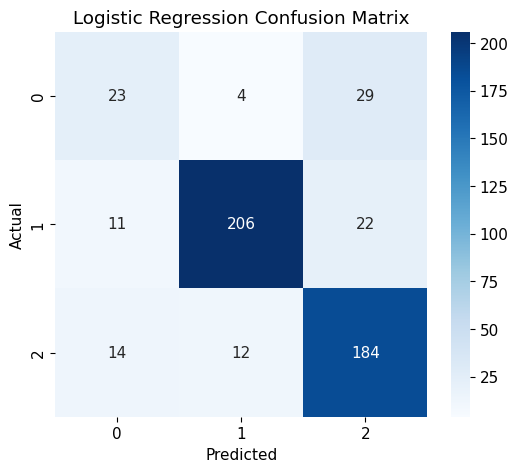

        PROCESS COMPLETED SUCCESSFULLY


In [96]:
# ============================================================
# MULTI-CLASS LOGISTIC REGRESSION (SAFE COMPLETE VERSION)
# ============================================================

import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt

print("======================================")
print("   MULTI-CLASS LOGISTIC REGRESSION")
print("======================================\n")

# ------------------------------------------------------------
# STEP 1: CHECK DATA
# ------------------------------------------------------------
print("Original Dataset Shape:", df_3profile.shape)
print("Columns:", df_3profile.columns)

# ------------------------------------------------------------
# STEP 2: KEEP REQUIRED COLUMNS & REMOVE NaN
# ------------------------------------------------------------
df_clean = df_3profile[['text', 'profile']].copy()
df_clean.dropna(inplace=True)

print("After Removing NaN:", df_clean.shape)

# If dataset empty, stop
if df_clean.shape[0] == 0:
    raise ValueError("Dataset became empty after cleaning. Check your columns.")

# ------------------------------------------------------------
# STEP 3: DEFINE FEATURES & LABELS
# ------------------------------------------------------------
X = df_clean["text"]
y = df_clean["profile"]

print("Unique labels:", sorted(y.unique()))
print()

# ------------------------------------------------------------
# STEP 4: TRAIN TEST SPLIT
# ------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print()

# ------------------------------------------------------------
# STEP 5: TF-IDF VECTORIZATION
# ------------------------------------------------------------
print("Converting text into TF-IDF vectors...")

vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    stop_words="english"
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print("TF-IDF Shape:", X_train_vec.shape)
print()

# ------------------------------------------------------------
# STEP 6: LOGISTIC REGRESSION MODEL
# ------------------------------------------------------------
print("Training Logistic Regression model...")

log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

log_reg.fit(X_train_vec, y_train)

print("Training completed.\n")

# ------------------------------------------------------------
# STEP 7: PREDICTIONS
# ------------------------------------------------------------
preds = log_reg.predict(X_test_vec)

# ------------------------------------------------------------
# STEP 8: EVALUATION
# ------------------------------------------------------------
accuracy = accuracy_score(y_test, preds)

print("======================================")
print("           FINAL RESULTS")
print("======================================")
print("Accuracy:", round(accuracy, 4))
print("\nClassification Report:\n")
print(classification_report(y_test, preds))

# ------------------------------------------------------------
# STEP 9: CONFUSION MATRIX
# ------------------------------------------------------------
cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("======================================")
print("        PROCESS COMPLETED SUCCESSFULLY")
print("======================================")

# **MULTI-LABEL LOGISTIC REGRESSION**

     MULTI-CLASS CLASSIFICATION

Available Columns:
Index(['text', 'emotion_profile', 'profile'], dtype='object')

Dataset shape after cleaning: (2523, 2)

Unique Labels: [np.int64(0), np.int64(1), np.int64(2)]

Training samples: 2018
Testing samples: 505

Applying TF-IDF...
Vectorized shape: (2018, 5000)

Training Logistic Regression model...
Training completed.

            FINAL RESULTS
Accuracy: 0.8178

Classification Report:

              precision    recall  f1-score   support

           0       0.48      0.41      0.44        56
           1       0.93      0.86      0.89       239
           2       0.78      0.88      0.83       210

    accuracy                           0.82       505
   macro avg       0.73      0.72      0.72       505
weighted avg       0.82      0.82      0.82       505



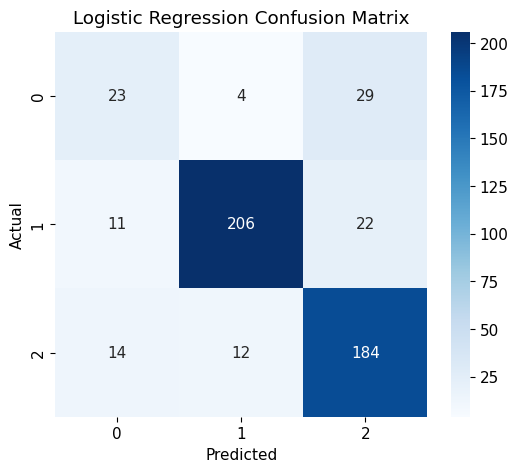

        PROCESS COMPLETED


In [97]:
# ============================================================
# FINAL MULTI-CLASS LOGISTIC REGRESSION (3 PROFILE)
# ============================================================

import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt

print("======================================")
print("     MULTI-CLASS CLASSIFICATION")
print("======================================\n")

# ------------------------------------------------------------
# STEP 1: CHECK DATA
# ------------------------------------------------------------
print("Available Columns:")
print(df_3profile.columns)
print()

# ------------------------------------------------------------
# STEP 2: CLEAN DATA
# ------------------------------------------------------------
df_clean = df_3profile[['text', 'profile']].copy()
df_clean.dropna(inplace=True)

print("Dataset shape after cleaning:", df_clean.shape)
print()

# ------------------------------------------------------------
# STEP 3: DEFINE FEATURES & LABELS
# ------------------------------------------------------------
X = df_clean["text"]
y = df_clean["profile"]

print("Unique Labels:", sorted(y.unique()))
print()

# ------------------------------------------------------------
# STEP 4: TRAIN TEST SPLIT
# ------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print()

# ------------------------------------------------------------
# STEP 5: TF-IDF VECTORIZATION
# ------------------------------------------------------------
print("Applying TF-IDF...")

vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    stop_words="english"
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print("Vectorized shape:", X_train_vec.shape)
print()

# ------------------------------------------------------------
# STEP 6: MODEL TRAINING
# ------------------------------------------------------------
print("Training Logistic Regression model...")

log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

log_reg.fit(X_train_vec, y_train)

print("Training completed.\n")

# ------------------------------------------------------------
# STEP 7: PREDICTION
# ------------------------------------------------------------
preds = log_reg.predict(X_test_vec)

# ------------------------------------------------------------
# STEP 8: EVALUATION
# ------------------------------------------------------------
accuracy = accuracy_score(y_test, preds)

print("======================================")
print("            FINAL RESULTS")
print("======================================")
print("Accuracy:", round(accuracy, 4))

print("\nClassification Report:\n")
print(classification_report(y_test, preds))

# ------------------------------------------------------------
# STEP 9: CONFUSION MATRIX
# ------------------------------------------------------------
cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("======================================")
print("        PROCESS COMPLETED")
print("======================================")

# **WEIGHT MATRIX VISUALIZATION**

In [98]:
log_reg.fit(X_train_vec, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [99]:
log_reg.coef_.shape

(3, 5000)

# Visualize Weight Matrix (Heatmap)

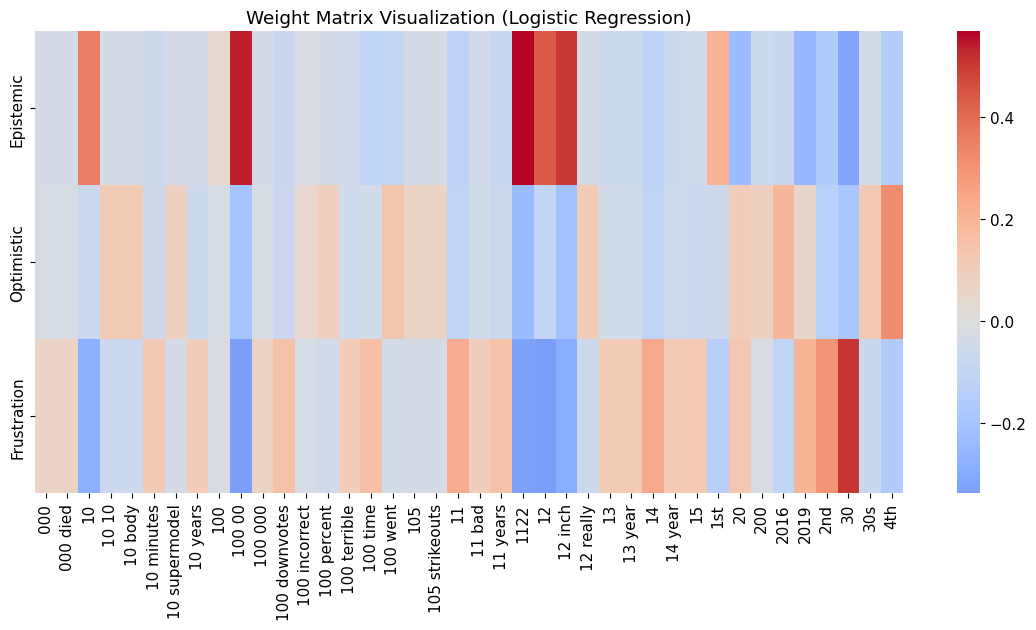

In [100]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

feature_names = vectorizer.get_feature_names_out()
weights = log_reg.coef_

plt.figure(figsize=(14,6))
sns.heatmap(
    weights[:, :40],   # first 40 features for visibility
    xticklabels=feature_names[:40],
    yticklabels=["Epistemic", "Optimistic", "Frustration"],
    cmap="coolwarm",
    center=0
)
plt.xticks(rotation=90)
plt.title("Weight Matrix Visualization (Logistic Regression)")
plt.show()

**Top Important Words Per Profile**

In [101]:
for i, label in enumerate(["Epistemic", "Optimistic", "Frustration"]):
    top_positive = np.argsort(weights[i])[-15:]
    top_negative = np.argsort(weights[i])[:15]

    print(f"\nTop Positive Words for {label}:")
    print([feature_names[j] for j in top_positive])

    print(f"\nTop Negative Words for {label}:")
    print([feature_names[j] for j in top_negative])


Top Positive Words for Epistemic:
['president', 'didn', 'libertarian', 'country', 'wonder', 'term', 'mean', 'question', 'confused', 'did', 'wondering', 'isn', 'know', 'wait', 'does']

Top Negative Words for Epistemic:
['love', 'thank', 'thanks', 'good', 'happy', 'hate', 'fucking', 'glad', 'lol', 'bad', 'great', 'awesome', 'fun', 'damn', 'haha']

Top Positive Words for Optimistic:
['best', 'congrats', 'loved', 'amazing', 'fun', 'haha', 'glad', 'great', 'awesome', 'happy', 'good', 'lol', 'thank', 'thanks', 'love']

Top Negative Words for Optimistic:
['sorry', 'don', 'isn', 'does', 'people', 'didn', 'fuck', 'hate', 'doesn', 'want', 'mean', 'term', 'need', 'worse', 'wondering']

Top Positive Words for Frustration:
['stop', 'weird', 'damn', 'miss', 'sad', 'don', 'hell', 'fuck', 'stupid', 'worst', 'worse', 'fucking', 'sorry', 'bad', 'hate']

Top Negative Words for Frustration:
['love', 'thanks', 'thank', 'lol', 'good', 'wait', 'wow', 'know', 'did', 'awesome', 'amazing', 'great', 'loved', 'h

In [102]:
X_emotions  # shape (n_samples, 28)

,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,desire,disappointment,...,love,nervousness,neutral,optimism,pride,realization,relief,remorse,sadness,surprise
40,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
54,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
60,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
65,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43344,1,1,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
43346,1,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
43372,0,0,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
43377,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [103]:
import pandas as pd
import numpy as np

# Get emotion names
emotion_features = X_emotions.columns

# Get weight matrix
weights = log_model.coef_   # shape (3, 28)

# Create DataFrame
weight_matrix = pd.DataFrame(
    weights,
    index=["P1_Epistemic", "P2_Optimistic", "P3_Frustration"],
    columns=emotion_features
)

weight_matrix.round(3)

,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,desire,disappointment,...,love,nervousness,neutral,optimism,pride,realization,relief,remorse,sadness,surprise
P1_Epistemic,-0.840,-0.875,-0.638,-0.844,0.106,-0.034,2.431,2.530,-0.005,-0.496,...,-0.499,-0.005,0.117,-0.001,-0.004,0.014,-0.000,-0.375,-0.744,1.953
P2_Optimistic,1.995,1.861,-0.967,-1.177,-0.083,0.030,-1.079,-1.251,0.037,-1.057,...,1.472,-0.008,-0.103,0.034,0.006,0.015,0.001,-0.824,-1.201,-1.003
P3_Frustration,-1.155,-0.986,1.605,2.021,-0.022,0.004,-1.351,-1.279,-0.032,1.553,...,-0.974,0.012,-0.013,-0.034,-0.002,-0.029,-0.001,1.198,1.945,-0.950


In [104]:
weight_matrix.style.background_gradient(cmap="coolwarm")

,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,desire,disappointment,disapproval,disgust,embarrassment,excitement,fear,gratitude,grief,joy,love,nervousness,neutral,optimism,pride,realization,relief,remorse,sadness,surprise
P1_Epistemic,-0.840348,-0.874963,-0.638026,-0.843704,0.105662,-0.034065,2.430717,2.530032,-0.005437,-0.496299,-0.758986,-0.553194,-0.031592,-0.624195,0.017637,-0.605616,-0.006214,-0.929383,-0.498801,-0.004595,0.116707,-0.000651,-0.003683,0.014425,-0.000446,-0.374633,-0.743527,1.953461
P2_Optimistic,1.994980,1.860783,-0.967349,-1.176962,-0.083203,0.030042,-1.079317,-1.251253,0.037129,-1.056959,-0.775028,-0.762204,0.005702,1.471542,-0.022785,1.532787,-0.009856,1.827170,1.472426,-0.007512,-0.103379,0.034430,0.005790,0.014860,0.001150,-0.823525,-1.201056,-1.003152
P3_Frustration,-1.154632,-0.985820,1.605376,2.020666,-0.022459,0.004023,-1.351400,-1.278779,-0.031692,1.553258,1.534013,1.315398,0.025890,-0.847346,0.005149,-0.927170,0.016070,-0.897787,-0.973626,0.012107,-0.013329,-0.033779,-0.002107,-0.029285,-0.000704,1.198157,1.944582,-0.950310


In [105]:
import pandas as pd
import numpy as np

# -------------------------------------------------
# STEP 1: Create Weight Matrix DataFrame
# -------------------------------------------------

emotion_features = mlb.classes_   # 28 emotion names

weight_matrix = pd.DataFrame(
    log_model.coef_,
    index=["P1_Epistemic", "P2_Optimistic", "P3_Frustration"],
    columns=emotion_features
)

print("Weight Matrix Shape:", weight_matrix.shape)

# -------------------------------------------------
# STEP 2: Add Profile Numbers Column
# -------------------------------------------------

profile_numbers = pd.Series(range(1, len(weight_matrix) + 1), name="Profile_No")

final_table = pd.concat(
    [profile_numbers, weight_matrix.reset_index(drop=True)],
    axis=1
)

# -------------------------------------------------
# STEP 3: Display Table
# -------------------------------------------------

print("\n===== FINAL WEIGHT MATRIX TABLE =====\n")
print(final_table.round(3))

# -------------------------------------------------
# STEP 4: Styled Visualization (optional)
# -------------------------------------------------

final_table.style.background_gradient(cmap="coolwarm")

# -------------------------------------------------
# STEP 5: Save Table (optional for report)
# -------------------------------------------------

final_table.to_csv("weight_matrix_table.csv", index=False)

Weight Matrix Shape: (3, 28)

===== FINAL WEIGHT MATRIX TABLE =====

   Profile_No  admiration  amusement  anger  annoyance  approval  caring  \
0           1      -0.840     -0.875 -0.638     -0.844     0.106  -0.034   
1           2       1.995      1.861 -0.967     -1.177    -0.083   0.030   
2           3      -1.155     -0.986  1.605      2.021    -0.022   0.004   

   confusion  curiosity  desire  ...   love  nervousness  neutral  optimism  \
0      2.431      2.530  -0.005  ... -0.499       -0.005    0.117    -0.001   
1     -1.079     -1.251   0.037  ...  1.472       -0.008   -0.103     0.034   
2     -1.351     -1.279  -0.032  ... -0.974        0.012   -0.013    -0.034   

   pride  realization  relief  remorse  sadness  surprise  
0 -0.004        0.014  -0.000   -0.375   -0.744     1.953  
1  0.006        0.015   0.001   -0.824   -1.201    -1.003  
2 -0.002       -0.029  -0.001    1.198    1.945    -0.950  

[3 rows x 29 columns]


# Hamming Loss & Jaccard

In [106]:
from sklearn.metrics import hamming_loss, jaccard_score

print("Hamming Loss:", hamming_loss(y_test, log_preds))
print("Jaccard Score (macro):", jaccard_score(y_test, log_preds, average="macro"))

Hamming Loss: 0.0019801980198019802
Jaccard Score (macro): 0.9927573466441557


MODEL EVALUATION RESULTS
Accuracy       : 0.998020
Macro F1 Score : 0.996351
Hamming Loss   : 0.001980
Jaccard Score  : 0.992757

Classification Report:

              precision    recall  f1-score   support

           0       0.98      1.00      0.99        56
           1       1.00      1.00      1.00       239
           2       1.00      1.00      1.00       210

    accuracy                           1.00       505
   macro avg       0.99      1.00      1.00       505
weighted avg       1.00      1.00      1.00       505



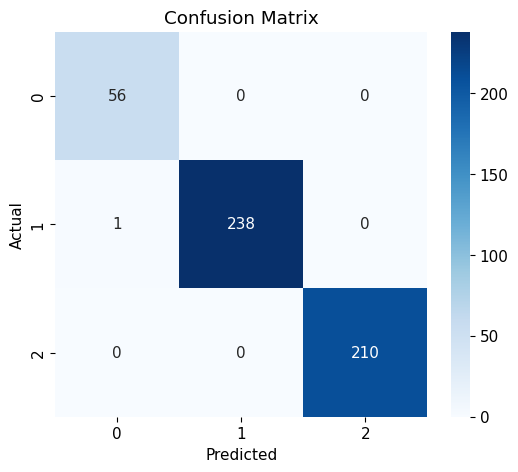

In [107]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    hamming_loss,
    jaccard_score,
    classification_report,
    confusion_matrix
)
import seaborn as sns
import matplotlib.pyplot as plt

# ============================
# EVALUATION METRICS
# ============================

accuracy = accuracy_score(y_test, log_preds)
macro_f1 = f1_score(y_test, log_preds, average="macro")
hamming = hamming_loss(y_test, log_preds)
jaccard = jaccard_score(y_test, log_preds, average="macro")

print("======================================")
print("MODEL EVALUATION RESULTS")
print("======================================")
print(f"Accuracy       : {accuracy:.6f}")
print(f"Macro F1 Score : {macro_f1:.6f}")
print(f"Hamming Loss   : {hamming:.6f}")
print(f"Jaccard Score  : {jaccard:.6f}")
print("======================================\n")

# ============================
# CLASSIFICATION REPORT
# ============================

print("Classification Report:\n")
print(classification_report(y_test, log_preds))

# ============================
# CONFUSION MATRIX
# ============================

cm = confusion_matrix(y_test, log_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# **BERT TRAINING**





In [108]:
# ============================================================
# REPRODUCIBILITY SETTINGS
# ============================================================

import os
import random
import numpy as np
import torch

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

torch.use_deterministic_algorithms(True, warn_only=True)

print("Reproducibility seed:", SEED)

Reproducibility seed: 42


Random seed: 42
Training samples: 2018
Testing samples: 505
Using device: cuda


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



===== Epoch 1/3 =====


  0%|          | 0/127 [00:00<?, ?it/s]/usr/local/lib/python3.13/dist-packages/torch/autograd/graph.py:869: UserWarning: Memory Efficient attention defaults to a non-deterministic algorithm. To explicitly enable determinism call torch.use_deterministic_algorithms(True, warn_only=False). (Triggered internally at /pytorch/aten/src/ATen/native/transformers/cuda/attention_backward.cu:900.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
100%|██████████| 127/127 [00:23<00:00,  5.50it/s]


Average Training Loss: 0.4357
Validation Accuracy: 0.9287

===== Epoch 2/3 =====


100%|██████████| 127/127 [00:18<00:00,  6.71it/s]


Average Training Loss: 0.1357
Validation Accuracy: 0.9465

===== Epoch 3/3 =====


100%|██████████| 127/127 [00:19<00:00,  6.59it/s]


Average Training Loss: 0.0653
Validation Accuracy: 0.9327

===== FINAL BERT RESULTS =====
BERT Accuracy: 0.9327
BERT Macro F1: 0.8927

Classification Report:

                                  precision    recall  f1-score   support

               Epistemic Profile       0.89      0.70      0.78        56
 Optimistic and Positive Profile       0.99      0.94      0.96       239
Frustration and Negative Profile       0.89      0.99      0.93       210

                        accuracy                           0.93       505
                       macro avg       0.92      0.87      0.89       505
                    weighted avg       0.93      0.93      0.93       505



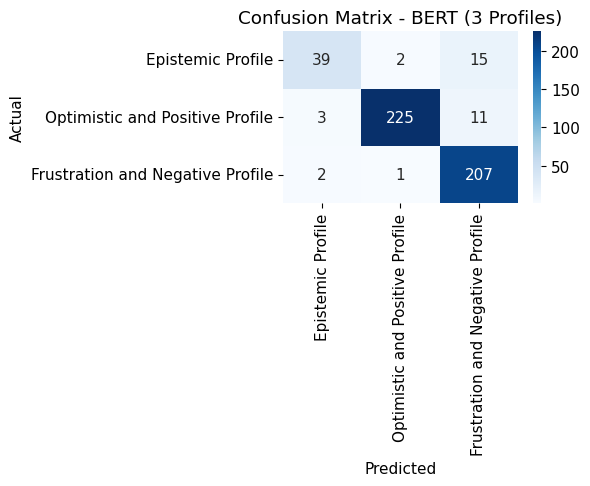

In [109]:
# ============================================================
# REPRODUCIBILITY SETTINGS
# ============================================================

import os
import random
import numpy as np
import torch

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

torch.use_deterministic_algorithms(True, warn_only=True)

print("Random seed:", SEED)


# ============================================================
# TRAIN / TEST SPLIT
# IMPORTANT: X and y must already be created before this
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


# ============================================================
# FINAL CLEAN BERT TRAINING PIPELINE (3-CLASS)
# ============================================================

import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification
from torch.optim import AdamW
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm


# ------------------------------------------------------------
# 1️⃣ DEVICE
# ------------------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)


# ------------------------------------------------------------
# 2️⃣ TOKENIZER
# ------------------------------------------------------------

tokenizer = BertTokenizer.from_pretrained(
    "bert-base-uncased"
)


# ------------------------------------------------------------
# 3️⃣ DATASET CLASS
# ------------------------------------------------------------

class TextDataset(Dataset):

    def __init__(self, texts, labels):

        self.encodings = tokenizer(
            list(texts),
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors="pt"
        )

        self.labels = torch.tensor(
            labels.values,
            dtype=torch.long
        )

    def __getitem__(self, idx):

        item = {
            key: val[idx]
            for key, val in self.encodings.items()
        }

        item["labels"] = self.labels[idx]

        return item

    def __len__(self):

        return len(self.labels)


# ------------------------------------------------------------
# 4️⃣ DATASETS
# ------------------------------------------------------------

train_dataset = TextDataset(
    X_train,
    y_train
)

test_dataset = TextDataset(
    X_test,
    y_test
)


# ------------------------------------------------------------
# 5️⃣ REPRODUCIBLE DATA LOADERS
# ------------------------------------------------------------

g_bert = torch.Generator()

g_bert.manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    generator=g_bert
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)


# ------------------------------------------------------------
# 6️⃣ LOAD BERT MODEL
# ------------------------------------------------------------

# Reset seed before model initialization
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=3
)

model.to(device)


# ------------------------------------------------------------
# 7️⃣ OPTIMIZER
# ------------------------------------------------------------

optimizer = AdamW(
    model.parameters(),
    lr=2e-5
)


# ------------------------------------------------------------
# 8️⃣ TRAINING LOOP
# ------------------------------------------------------------

epochs = 3

for epoch in range(epochs):

    print(
        f"\n===== Epoch {epoch+1}/{epochs} ====="
    )

    model.train()

    total_loss = 0

    for batch in tqdm(train_loader):

        optimizer.zero_grad()

        batch = {
            k: v.to(device)
            for k, v in batch.items()
        }

        outputs = model(**batch)

        loss = outputs.loss

        total_loss += loss.item()

        loss.backward()

        optimizer.step()


    avg_loss = (
        total_loss /
        len(train_loader)
    )

    print(
        f"Average Training Loss: {avg_loss:.4f}"
    )


    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------

    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for batch in test_loader:

            labels = batch["labels"].to(device)

            batch = {
                k: v.to(device)
                for k, v in batch.items()
            }

            outputs = model(**batch)

            preds = torch.argmax(
                outputs.logits,
                dim=1
            )

            all_preds.extend(
                preds.cpu().numpy()
            )

            all_labels.extend(
                labels.cpu().numpy()
            )


    val_accuracy = accuracy_score(
        all_labels,
        all_preds
    )

    print(
        f"Validation Accuracy: {val_accuracy:.4f}"
    )


# ============================================================
# 9️⃣ FINAL RESULTS
# ============================================================

print("\n===== FINAL BERT RESULTS =====")

bert_accuracy = accuracy_score(
    all_labels,
    all_preds
)

bert_macro_f1 = f1_score(
    all_labels,
    all_preds,
    average="macro"
)

bert_preds = np.array(
    all_preds
)

print(
    "BERT Accuracy:",
    round(bert_accuracy, 4)
)

print(
    "BERT Macro F1:",
    round(bert_macro_f1, 4)
)


# ============================================================
# 🔟 CLASSIFICATION REPORT
# ============================================================

class_names = [
    "Epistemic Profile",
    "Optimistic and Positive Profile",
    "Frustration and Negative Profile"
]

print("\nClassification Report:\n")

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=class_names
    )
)


# ============================================================
# 1️⃣1️⃣ CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    all_labels,
    all_preds
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title(
    "Confusion Matrix - BERT (3 Profiles)"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.tight_layout()

plt.show()

# **ROBERT TRAINING**

Using device: cuda


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



===== Epoch 1/3 =====


100%|██████████| 127/127 [00:20<00:00,  6.29it/s]


Average Training Loss: 0.4246
Validation Accuracy: 0.9248

===== Epoch 2/3 =====


100%|██████████| 127/127 [00:26<00:00,  4.87it/s]


Average Training Loss: 0.1413
Validation Accuracy: 0.9446

===== Epoch 3/3 =====


100%|██████████| 127/127 [00:19<00:00,  6.43it/s]


Average Training Loss: 0.0649
Validation Accuracy: 0.9446

===== FINAL ROBERTA RESULTS =====
RoBERTa Accuracy: 0.9446
RoBERTa Macro F1: 0.905

Classification Report:

                                  precision    recall  f1-score   support

               Epistemic Profile       0.93      0.70      0.80        56
 Optimistic and Positive Profile       0.98      0.98      0.98       239
Frustration and Negative Profile       0.91      0.97      0.94       210

                        accuracy                           0.94       505
                       macro avg       0.94      0.88      0.90       505
                    weighted avg       0.94      0.94      0.94       505



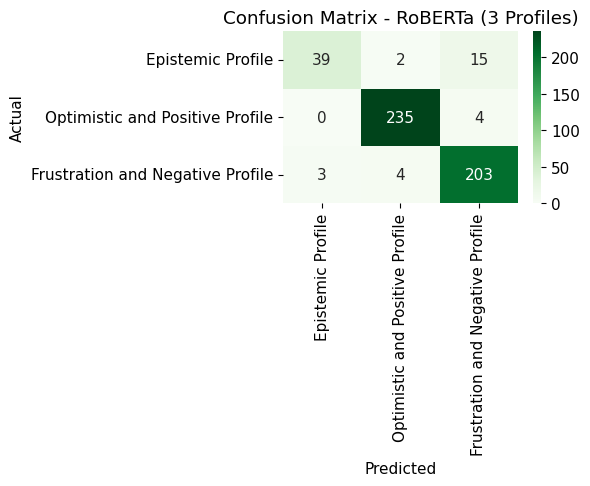

In [110]:
# ============================================================
# FINAL CLEAN ROBERTA TRAINING PIPELINE (3-CLASS)
# ============================================================

import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
from transformers import RobertaTokenizer, RobertaForSequenceClassification
from torch.optim import AdamW
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm


# ------------------------------------------------------------
# 1️⃣ DEVICE
# ------------------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)


# ------------------------------------------------------------
# 2️⃣ TOKENIZER
# ------------------------------------------------------------

tokenizer_roberta = RobertaTokenizer.from_pretrained(
    "roberta-base"
)


# ------------------------------------------------------------
# 3️⃣ DATASET CLASS
# ------------------------------------------------------------

class RobertaDataset(Dataset):

    def __init__(self, texts, labels):

        self.encodings = tokenizer_roberta(
            list(texts),
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors="pt"
        )

        self.labels = torch.tensor(
            labels.values,
            dtype=torch.long
        )

    def __getitem__(self, idx):

        item = {
            key: val[idx]
            for key, val in self.encodings.items()
        }

        item["labels"] = self.labels[idx]

        return item

    def __len__(self):

        return len(self.labels)


# ------------------------------------------------------------
# 4️⃣ DATASETS
# IMPORTANT:
# X_train, X_test, y_train, y_test come from the
# fixed train_test_split() used before this cell.
# ------------------------------------------------------------

train_dataset_r = RobertaDataset(
    X_train,
    y_train
)

test_dataset_r = RobertaDataset(
    X_test,
    y_test
)


# ------------------------------------------------------------
# 5️⃣ REPRODUCIBLE DATA LOADERS
# ------------------------------------------------------------

g_roberta = torch.Generator()

g_roberta.manual_seed(SEED)

train_loader_r = DataLoader(
    train_dataset_r,
    batch_size=16,
    shuffle=True,
    generator=g_roberta
)

test_loader_r = DataLoader(
    test_dataset_r,
    batch_size=16,
    shuffle=False
)


# ------------------------------------------------------------
# 6️⃣ LOAD ROBERTA MODEL
# ------------------------------------------------------------

# Reset seed before model initialization
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)


model_roberta = RobertaForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=3
)

model_roberta.to(device)


# ------------------------------------------------------------
# 7️⃣ OPTIMIZER
# ------------------------------------------------------------

optimizer_r = AdamW(
    model_roberta.parameters(),
    lr=2e-5
)


# ------------------------------------------------------------
# 8️⃣ TRAINING LOOP
# ------------------------------------------------------------

epochs = 3

for epoch in range(epochs):

    print(
        f"\n===== Epoch {epoch+1}/{epochs} ====="
    )

    model_roberta.train()

    total_loss = 0

    for batch in tqdm(train_loader_r):

        optimizer_r.zero_grad()

        batch = {
            k: v.to(device)
            for k, v in batch.items()
        }

        outputs = model_roberta(**batch)

        loss = outputs.loss

        total_loss += loss.item()

        loss.backward()

        optimizer_r.step()


    avg_loss = (
        total_loss /
        len(train_loader_r)
    )

    print(
        f"Average Training Loss: {avg_loss:.4f}"
    )


    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------

    model_roberta.eval()

    all_preds_r = []
    all_labels_r = []

    with torch.no_grad():

        for batch in test_loader_r:

            labels = batch["labels"].to(device)

            batch = {
                k: v.to(device)
                for k, v in batch.items()
            }

            outputs = model_roberta(**batch)

            preds = torch.argmax(
                outputs.logits,
                dim=1
            )

            all_preds_r.extend(
                preds.cpu().numpy()
            )

            all_labels_r.extend(
                labels.cpu().numpy()
            )


    val_accuracy = accuracy_score(
        all_labels_r,
        all_preds_r
    )

    print(
        f"Validation Accuracy: {val_accuracy:.4f}"
    )


# ============================================================
# 9️⃣ FINAL RESULTS
# ============================================================

print("\n===== FINAL ROBERTA RESULTS =====")

roberta_accuracy = accuracy_score(
    all_labels_r,
    all_preds_r
)

roberta_macro_f1 = f1_score(
    all_labels_r,
    all_preds_r,
    average="macro"
)

roberta_preds = np.array(
    all_preds_r
)

print(
    "RoBERTa Accuracy:",
    round(roberta_accuracy, 4)
)

print(
    "RoBERTa Macro F1:",
    round(roberta_macro_f1, 4)
)


# ============================================================
# 🔟 CLASSIFICATION REPORT
# ============================================================

class_names = [
    "Epistemic Profile",
    "Optimistic and Positive Profile",
    "Frustration and Negative Profile"
]

print("\nClassification Report:\n")

print(
    classification_report(
        all_labels_r,
        all_preds_r,
        target_names=class_names
    )
)


# ============================================================
# 1️⃣1️⃣ CONFUSION MATRIX
# ============================================================

cm_r = confusion_matrix(
    all_labels_r,
    all_preds_r
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_r,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title(
    "Confusion Matrix - RoBERTa (3 Profiles)"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.tight_layout()

plt.show()

# **SVM PIPELINE**

        SVM MODEL TRAINING STARTED

TF-IDF Train Shape: (2018, 5000)
TF-IDF Test Shape: (505, 5000)

Training SVM...
Training Completed

           FINAL SVM RESULTS
SVM Accuracy: 0.8238
SVM Macro F1: 0.7004

Classification Report:

                                  precision    recall  f1-score   support

               Epistemic Profile       0.53      0.29      0.37        56
 Optimistic and Positive Profile       0.90      0.90      0.90       239
Frustration and Negative Profile       0.78      0.88      0.83       210

                        accuracy                           0.82       505
                       macro avg       0.74      0.69      0.70       505
                    weighted avg       0.81      0.82      0.81       505



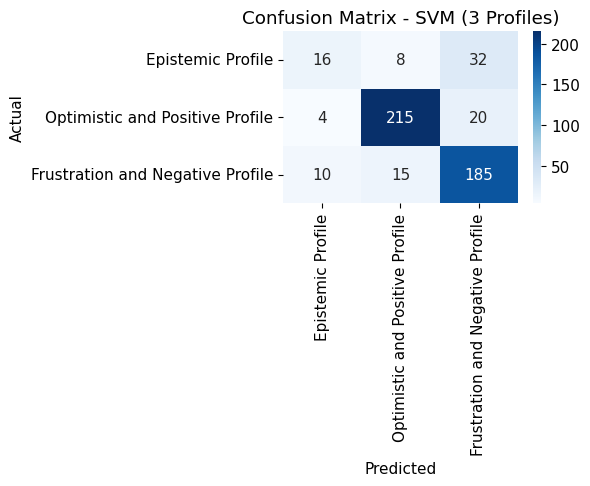


         SVM PROCESS COMPLETED


In [111]:
# ============================================================
# FINAL CLEAN SVM PIPELINE (3-CLASS)
# ============================================================

import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

print("======================================")
print("        SVM MODEL TRAINING STARTED")
print("======================================\n")

# ------------------------------------------------------------
# 1️⃣ TF-IDF VECTORIZATION
# ------------------------------------------------------------
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    stop_words="english"
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("TF-IDF Train Shape:", X_train_tfidf.shape)
print("TF-IDF Test Shape:", X_test_tfidf.shape)
print()

# ------------------------------------------------------------
# 2️⃣ INITIALIZE SVM
# ------------------------------------------------------------
svm_model = LinearSVC(class_weight="balanced")

# ------------------------------------------------------------
# 3️⃣ TRAIN
# ------------------------------------------------------------
print("Training SVM...")
svm_model.fit(X_train_tfidf, y_train)
print("Training Completed\n")

# ------------------------------------------------------------
# 4️⃣ PREDICT
# ------------------------------------------------------------
svm_preds = svm_model.predict(X_test_tfidf)

# ------------------------------------------------------------
# 5️⃣ EVALUATION
# ------------------------------------------------------------
print("======================================")
print("           FINAL SVM RESULTS")
print("======================================")

svm_accuracy = accuracy_score(y_test, svm_preds)
svm_macro_f1 = f1_score(y_test, svm_preds, average="macro")

print("SVM Accuracy:", round(svm_accuracy, 4))
print("SVM Macro F1:", round(svm_macro_f1, 4))

# ------------------------------------------------------------
# 6️⃣ CLASSIFICATION REPORT
# ------------------------------------------------------------
class_names = [
    "Epistemic Profile",
    "Optimistic and Positive Profile",
    "Frustration and Negative Profile"
]

print("\nClassification Report:\n")
print(classification_report(y_test, svm_preds, target_names=class_names))

# ------------------------------------------------------------
# 7️⃣ CONFUSION MATRIX
# ------------------------------------------------------------
cm = confusion_matrix(y_test, svm_preds)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix - SVM (3 Profiles)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

print("\n======================================")
print("         SVM PROCESS COMPLETED")
print("======================================")

In [112]:
%who

AdamW	 BertForSequenceClassification	 BertTokenizer	 Counter	 DataLoader	 Dataset	 EPISTEMIC_PROFILE	 FRUSTRATION_NEGATIVE_PROFILE	 G	 
LinearSVC	 LogisticRegression	 MultiLabelBinarizer	 NMF	 OPTIMISTIC_POSITIVE_PROFILE	 RobertaDataset	 RobertaForSequenceClassification	 RobertaTokenizer	 SEED	 
TextDataset	 TfidfVectorizer	 X	 X_emotions	 X_test	 X_test_tfidf	 X_test_vec	 X_train	 X_train_tfidf	 
X_train_vec	 accuracy	 accuracy_score	 all_labels	 all_labels_r	 all_preds	 all_preds_r	 avg_loss	 ax	 
bar	 bars	 batch	 bert_accuracy	 bert_macro_f1	 bert_preds	 bottom	 c	 cid	 
class_names	 classification_report	 cluster_counts	 cluster_id	 cluster_labels	 cluster_legend	 cluster_name_map	 cluster_names	 cluster_table	 
clusters	 cm	 cm_r	 co_occurrence	 co_occurrence_df	 color_map	 colors	 community_louvain	 conf_matrix	 
confusion_matrix	 count	 counter	 counts	 dataset	 dendrogram	 detect_emotion_profile	 device	 df	 
df_3profile	 df_clean	 df_compare	 df_profile	 drop_clusters	 edge_w

In [113]:
import pandas as pd
from sklearn.metrics import f1_score

# -----------------------------
# Compute F1 Scores Correctly
# -----------------------------

bert_f1_macro = f1_score(y_test, bert_preds, average="macro")
bert_f1_weighted = f1_score(y_test, bert_preds, average="weighted")

roberta_f1_macro = f1_score(y_test, roberta_preds, average="macro")
roberta_f1_weighted = f1_score(y_test, roberta_preds, average="weighted")

svm_f1_macro = f1_score(y_test, svm_preds, average="macro")
svm_f1_weighted = f1_score(y_test, svm_preds, average="weighted")

# -----------------------------
# Final Comparison Table
# -----------------------------

comparison_df = pd.DataFrame({
    "Model": ["BERT", "RoBERTa", "SVM"],
    "Accuracy": [
        bert_accuracy,
        roberta_accuracy,
        svm_accuracy
    ],
    "Macro F1": [
        bert_f1_macro,
        roberta_f1_macro,
        svm_f1_macro
    ],
    "Weighted F1": [
        bert_f1_weighted,
        roberta_f1_weighted,
        svm_f1_weighted
    ]
})

# Sort by Accuracy
comparison_df = comparison_df.sort_values(by="Accuracy", ascending=False)

print("\n===== FINAL MODEL COMPARISON =====")
print(comparison_df.round(4))


===== FINAL MODEL COMPARISON =====
     Model  Accuracy  Macro F1  Weighted F1
1  RoBERTa    0.9446    0.9050       0.9425
0     BERT    0.9327    0.8927       0.9312
2      SVM    0.8238    0.7004       0.8121


# **GUI**

In [114]:
def predict_profile(text):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Move model to device
    model.to(device)

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True
    )

    # 🔥 MOVE INPUTS TO SAME DEVICE
    inputs = {key: val.to(device) for key, val in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits
    pred = torch.argmax(logits, dim=1).item()

    return pred

In [115]:
profile_names = {
    0: "Frustration and Negative Profile",
    1: "Optimistic and Positive Profile",
    2: "Epistemic Profile"
}

In [116]:
def gui_predict(text):
    try:
        pid = predict_profile(text)

        # Get profile name
        result = profile_names.get(pid, "Unknown Emotion Profile")

        # If it's already a list → format properly
        if isinstance(result, list):
            return f"[{', '.join(result)}]"

        # If it's a single string → wrap in []
        return f"[{result}]"

    except Exception as e:
        return f"Error: {str(e)}"

In [117]:
import torch
import gradio as gr

# -----------------------------
# Prediction Functions
# -----------------------------
def predict_profile(text):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model.to(device)

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True
    )

    inputs = {key: val.to(device) for key, val in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits
    pred = torch.argmax(logits, dim=1).item()

    return pred


def gui_predict(text):
    try:
        pid = predict_profile(text)

        result = profile_names.get(pid, "Unknown Emotion Profile")

        if isinstance(result, list):
            result = ", ".join(result)

        return result

    except Exception as e:
        return f"Error: {str(e)}"


# -----------------------------
# UI (FULL CENTERED LAYOUT)
# -----------------------------
with gr.Blocks() as demo:

    # ✅ Centered Title
    gr.Markdown(
        "<h2 style='text-align: center;'>Compound Emotion Profile Prediction</h2>"
    )

    # ✅ Centered Description (FIXED POSITION)
    gr.Markdown(
        "<p style='text-align: center;'>Enter text to detect emotional profile</p>"
    )

    # ✅ Centered Input
    with gr.Row():
        with gr.Column(scale=1):
            pass
        with gr.Column(scale=2):
            text_input = gr.Textbox(
                lines=4,
                placeholder="Enter a social media post...",
                label="Text"
            )
        with gr.Column(scale=1):
            pass

    # ✅ Centered Buttons
    with gr.Row():
        with gr.Column(scale=1):
            pass
        with gr.Column(scale=2):
            with gr.Row():
                submit_btn = gr.Button("Submit")
                clear_btn = gr.Button("Clear")
        with gr.Column(scale=1):
            pass

    # ✅ Centered Output
    with gr.Row():
        with gr.Column(scale=1):
            pass
        with gr.Column(scale=2):
            output = gr.Textbox(
                label="Predicted Emotional Profile",
                lines=2,
                max_lines=2
            )
        with gr.Column(scale=1):
            pass

    # Actions
    submit_btn.click(
        fn=gui_predict,
        inputs=text_input,
        outputs=output
    )

    clear_btn.click(
        fn=lambda: ("", ""),
        inputs=[],
        outputs=[text_input, output]
    )

# Launch
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://08c1b7c260e5c7b9e6.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
